# Customer Churn Prediction
### PTF03 Final Project â€” AUF College of Computer Studies

---

**Objective:** Predict customer churn in a telecommunications dataset using supervised and unsupervised machine learning approaches, then compare model performance within each paradigm.

**Models:**
| # | Model | Type | Purpose |
|---|-------|------|---------|
| 1 | Random Forest | Supervised | Classification via ensemble of decision trees |
| 2 | XGBoost | Supervised | Classification via gradient-boosted trees |
| 3 | Support Vector Machine | Supervised | Non-linear classification via RBF-kernel max-margin separator |
| 4 | Gaussian Mixture Model | Unsupervised | Probabilistic soft clustering |
| 5 | DBSCAN | Unsupervised | Density-based spatial clustering |
| 6 | K-Means Clustering | Unsupervised | Centroid-based partitioning with silhouette-selected k |

**Dataset:** [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) â€” 7,043 customers, 21 features.

---

### Table of Contents
1. [Setup & Dependencies](#1)
2. [Data Loading & Exploration](#2)
3. [Data Preprocessing](#3)
4. [Supervised Learning](#4)
   - 4.1 Random Forest Classifier
   - 4.2 XGBoost Classifier
   - 4.3 Support Vector Machine (SVM)
   - 4.4 Supervised Models Comparison
5. [Unsupervised Learning](#5)
   - 5.1 Gaussian Mixture Model (GMM)
   - 5.2 DBSCAN
   - 5.3 K-Means Clustering
   - 5.4 Unsupervised Models Comparison
6. [Written Report](#6)

<a id='1'></a>
## 1. Setup & Dependencies

In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Supervised
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    cross_val_score, StratifiedKFold, learning_curve
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Unsupervised
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors


# Shared cross-validation strategy
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Plot styling
COLORS = {
    'primary': '#6366f1',
    'secondary': '#8b5cf6',
    'success': '#10b981',
    'danger': '#ef4444',
    'warning': '#f59e0b',
    'muted': '#9ca3af',
    'dark': '#1a1d23'
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#e5e7eb',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'figure.titlesize': 15,
    'figure.titleweight': 'bold',
    'figure.dpi': 120
})

print('Environment ready.')

Environment ready.


<a id='2'></a>
## 2. Data Loading & Exploration

In [2]:
df_raw = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Shape: {df_raw.shape[0]:,} rows Ã— {df_raw.shape[1]} columns')
print(f'Memory: {df_raw.memory_usage(deep=True).sum() / 1e6:.2f} MB\n')
df_raw.head()

Shape: 7,043 rows Ã— 21 columns
Memory: 7.15 MB



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Statistical summary for numerical columns
df_raw.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


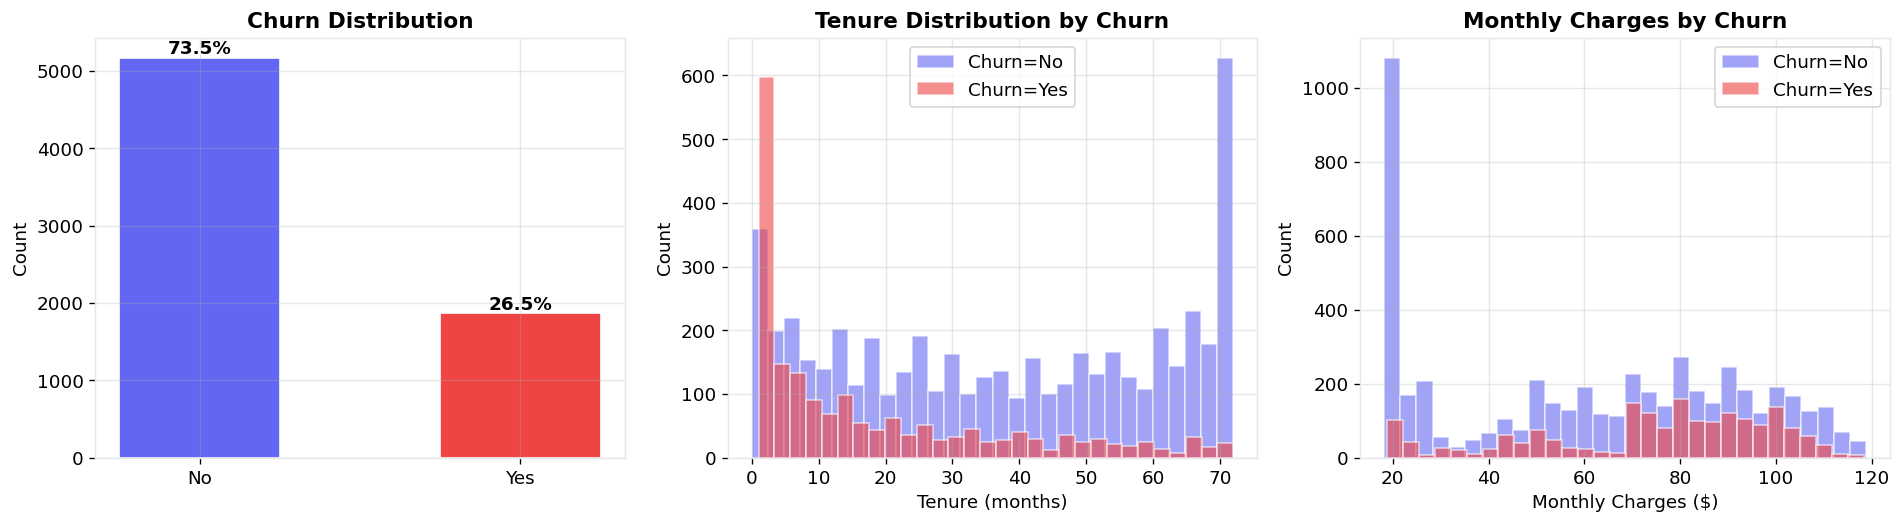

Dataset is imbalanced: 73.5% No Churn vs 26.5% Churn


In [5]:
# Target variable distribution
churn_counts = df_raw['Churn'].value_counts()
churn_pct = df_raw['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Churn distribution
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=[COLORS['primary'], COLORS['danger']], edgecolor='white', width=0.5)
for bar, pct in zip(bars, churn_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{pct:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Churn Distribution')
axes[0].set_ylabel('Count')

# Tenure distribution by churn
for label, color in [('No', COLORS['primary']), ('Yes', COLORS['danger'])]:
    subset = df_raw[df_raw['Churn'] == label]['tenure']
    axes[1].hist(subset, bins=30, alpha=0.6, label=f'Churn={label}', color=color, edgecolor='white')
axes[1].set_title('Tenure Distribution by Churn')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Count')
axes[1].legend()

# Monthly charges distribution by churn
for label, color in [('No', COLORS['primary']), ('Yes', COLORS['danger'])]:
    subset = df_raw[df_raw['Churn'] == label]['MonthlyCharges']
    axes[2].hist(subset, bins=30, alpha=0.6, label=f'Churn={label}', color=color, edgecolor='white')
axes[2].set_title('Monthly Charges by Churn')
axes[2].set_xlabel('Monthly Charges ($)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Dataset is imbalanced: {churn_pct.iloc[0]:.1f}% No Churn vs {churn_pct.iloc[1]:.1f}% Churn')

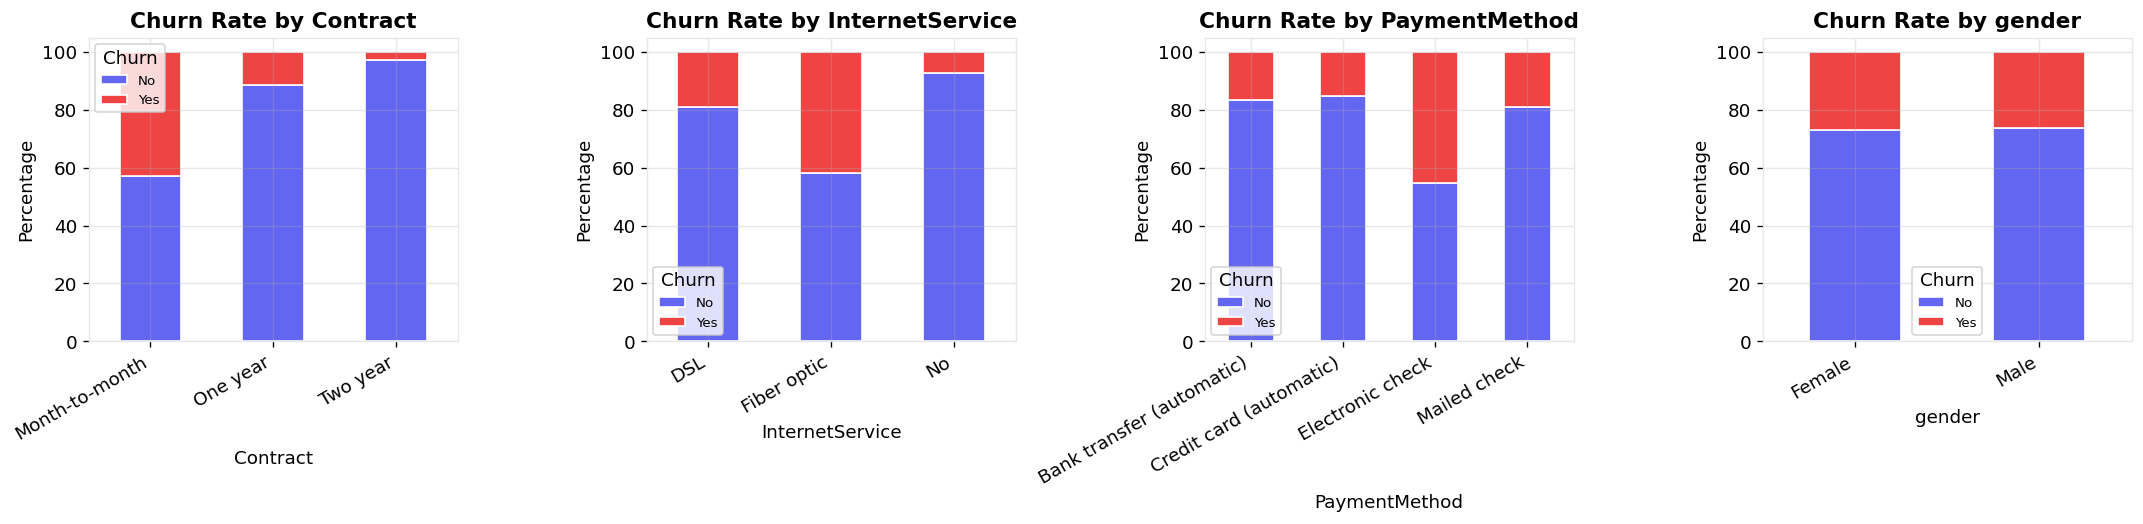

In [6]:
# Churn rate by key categorical features
cat_features = ['Contract', 'InternetService', 'PaymentMethod', 'gender']

fig, axes = plt.subplots(1, len(cat_features), figsize=(18, 4.5))

for ax, col in zip(axes, cat_features):
    ct = pd.crosstab(df_raw[col], df_raw['Churn'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=[COLORS['primary'], COLORS['danger']], edgecolor='white')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Percentage')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(['No', 'Yes'], title='Churn', fontsize=8)
    ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

<a id='3'></a>
## 3. Data Preprocessing

In [7]:
df = df_raw.copy()

# 1. Fix TotalCharges (contains whitespace strings instead of NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_missing = df['TotalCharges'].isnull().sum()
print(f'Missing TotalCharges: {n_missing} rows (dropped)')
df = df.dropna()

# 2. Drop customerID (not a feature)
df = df.drop('customerID', axis=1)

# 3. Encode categorical features (separate encoder per column to preserve mappings)
label_encoders = {}
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
    print(f'  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print(f'\nFinal dataset: {df_encoded.shape[0]:,} rows Ã— {df_encoded.shape[1]} columns')

Missing TotalCharges: 11 rows (dropped)
  gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  Partner: {'No': np.int64(0), 'Yes': np.int64(1)}
  Dependents: {'No': np.int64(0), 'Yes': np.int64(1)}
  PhoneService: {'No': np.int64(0), 'Yes': np.int64(1)}
  MultipleLines: {'No': np.int64(0), 'No phone service': np.int64(1), 'Yes': np.int64(2)}
  InternetService: {'DSL': np.int64(0), 'Fiber optic': np.int64(1), 'No': np.int64(2)}
  OnlineSecurity: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
  OnlineBackup: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
  DeviceProtection: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
  TechSupport: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
  StreamingTV: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
  StreamingMovies: {'No': np.int64(0), 'No internet service': np.int64(1), 'Yes': np.int64(2)}
  Contra

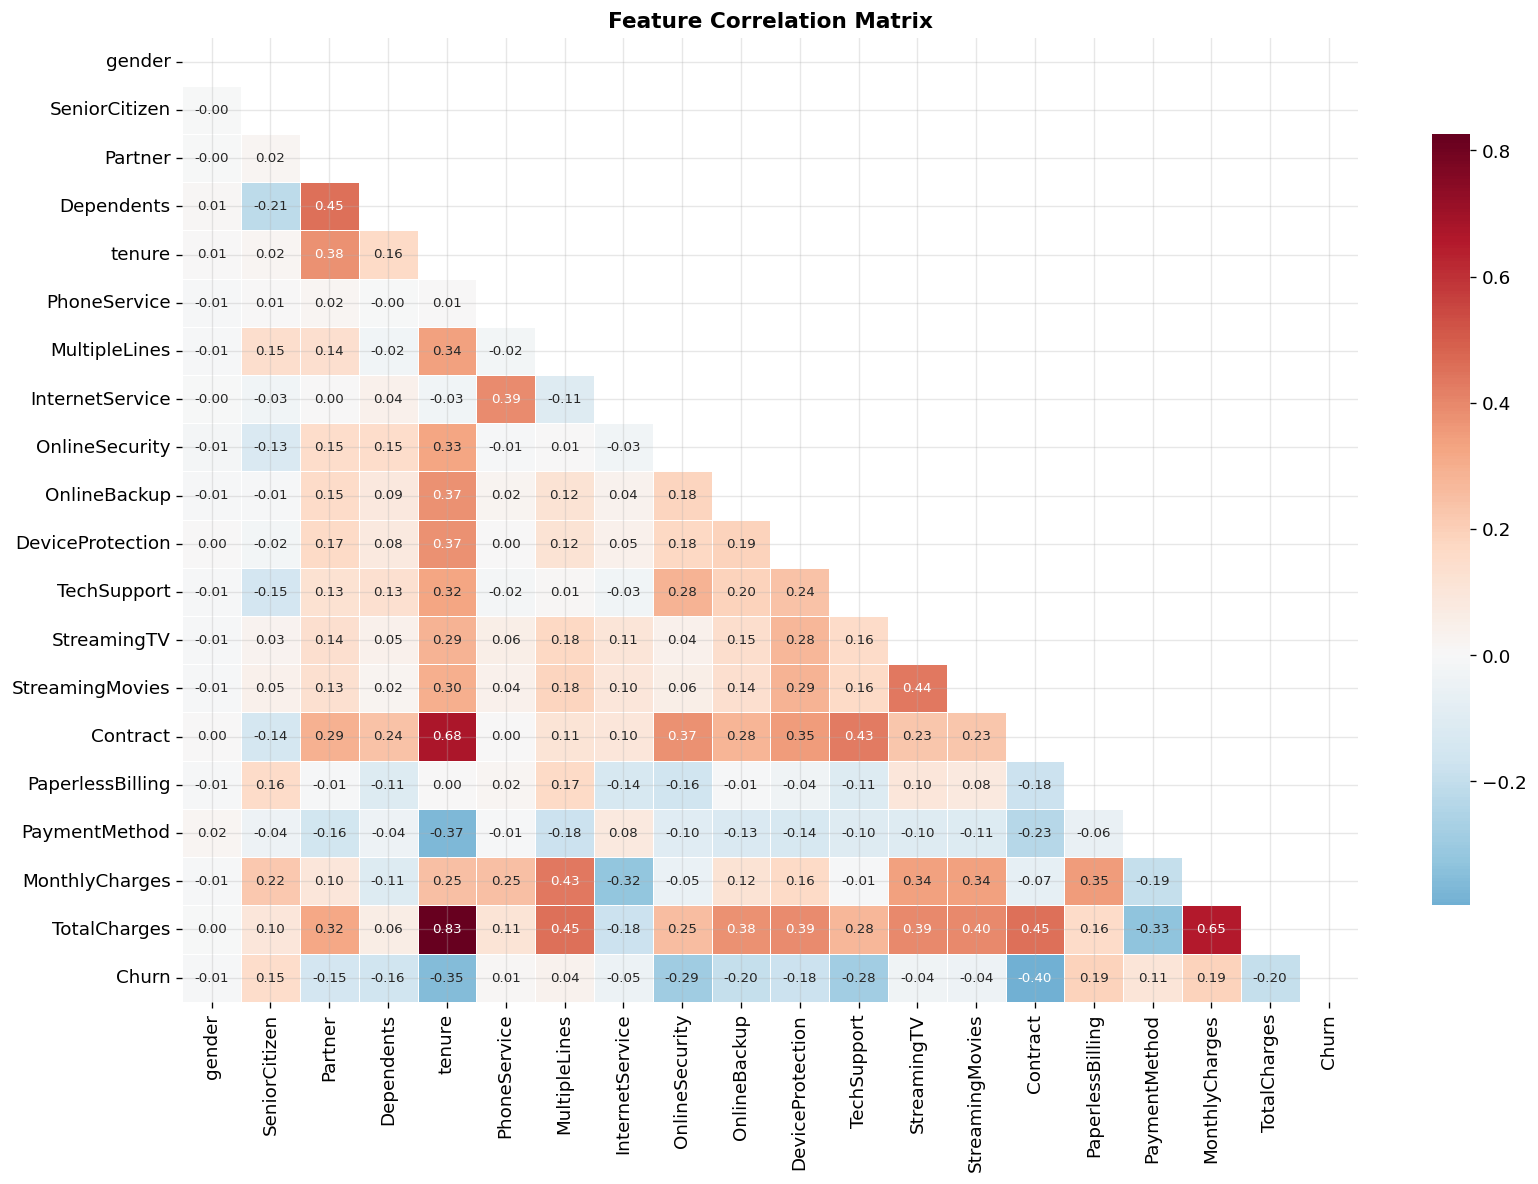

Top correlations with Churn:
  - Contract: -0.396
  - tenure: -0.354
  - OnlineSecurity: -0.289
  - TechSupport: -0.282
  - TotalCharges: -0.199
  - OnlineBackup: -0.195
  + MonthlyCharges: 0.193
  + PaperlessBilling: 0.191


In [8]:
# Correlation heatmap (encoded features)
fig, ax = plt.subplots(figsize=(14, 10))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Top correlations with Churn
churn_corr = corr['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print('Top correlations with Churn:')
for feat, val in churn_corr.head(8).items():
    direction = '+' if val > 0 else '-'
    print(f'  {direction} {feat}: {val:.3f}')

In [9]:
# Prepare features and target
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Stratified train/test split (shared across supervised models for fair comparison)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardized features (used by unsupervised models AND SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training: {X_train.shape[0]:,} samples | Test: {X_test.shape[0]:,} samples')
print(f'Churn rate â€” Train: {y_train.mean():.2%} | Test: {y_test.mean():.2%}')
print(f'Features: {X.shape[1]}')

Training: 5,625 samples | Test: 1,407 samples
Churn rate â€” Train: 26.58% | Test: 26.58%
Features: 19


<a id='4'></a>
## 4. Supervised Learning

Both models use:
- The **same train/test split** for fair comparison
- **Class imbalance handling** (balanced weights / scale_pos_weight)
- **5-fold cross-validation** for hyperparameter tuning
- Evaluation on the **held-out test set** only

### 4.1 Random Forest Classifier

In [10]:
# Baseline model
rf_base = RandomForestClassifier(n_estimators=200, random_state=42)
rf_base.fit(X_train, y_train)

y_pred_rf_base = rf_base.predict(X_test)
y_prob_rf_base = rf_base.predict_proba(X_test)[:, 1]

print('=== Random Forest (Baseline) ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_rf_base):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf_base):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_rf_base):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_rf_base):.4f}')
print(f'ROC AUC:   {roc_auc_score(y_test, y_prob_rf_base):.4f}')
print()
print(classification_report(y_test, y_pred_rf_base, target_names=['No Churn', 'Churn']))

=== Random Forest (Baseline) ===
Accuracy:  0.7875
Precision: 0.6280
Recall:    0.4920
F1 Score:  0.5517
ROC AUC:   0.8143

              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1033
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [11]:
# Hyperparameter tuning via GridSearchCV (optimizing F1 due to class imbalance)
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, cv=CV, scoring='f1', n_jobs=-1, verbose=1
)
grid_rf.fit(X_train, y_train)

rf_best = grid_rf.best_estimator_
y_pred_rf = rf_best.predict(X_test)
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]

print(f'\nBest parameters: {grid_rf.best_params_}')
print(f'Best CV F1 score: {grid_rf.best_score_:.4f}')
print()
print('=== Random Forest (Optimized) ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_rf):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_rf):.4f}')
print(f'ROC AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'Avg Prec:  {average_precision_score(y_test, y_prob_rf):.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

Fitting 5 folds for each of 162 candidates, totalling 810 fits



Best parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1 score: 0.6371

=== Random Forest (Optimized) ===
Accuracy:  0.7655
Precision: 0.5430
Recall:    0.7433
F1 Score:  0.6275
ROC AUC:   0.8339
Avg Prec:  0.6391

              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.83      1033
       Churn       0.54      0.74      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



In [12]:
# Cross-validation stability check
cv_scores_rf = cross_val_score(rf_best, X_train, y_train, cv=5, scoring='f1')
print(f'5-Fold CV F1: {cv_scores_rf.mean():.4f} Â± {cv_scores_rf.std():.4f}')
print(f'Per fold: {np.round(cv_scores_rf, 4)}')

5-Fold CV F1: 0.6277 Â± 0.0269
Per fold: [0.6163 0.6529 0.6532 0.5813 0.6346]


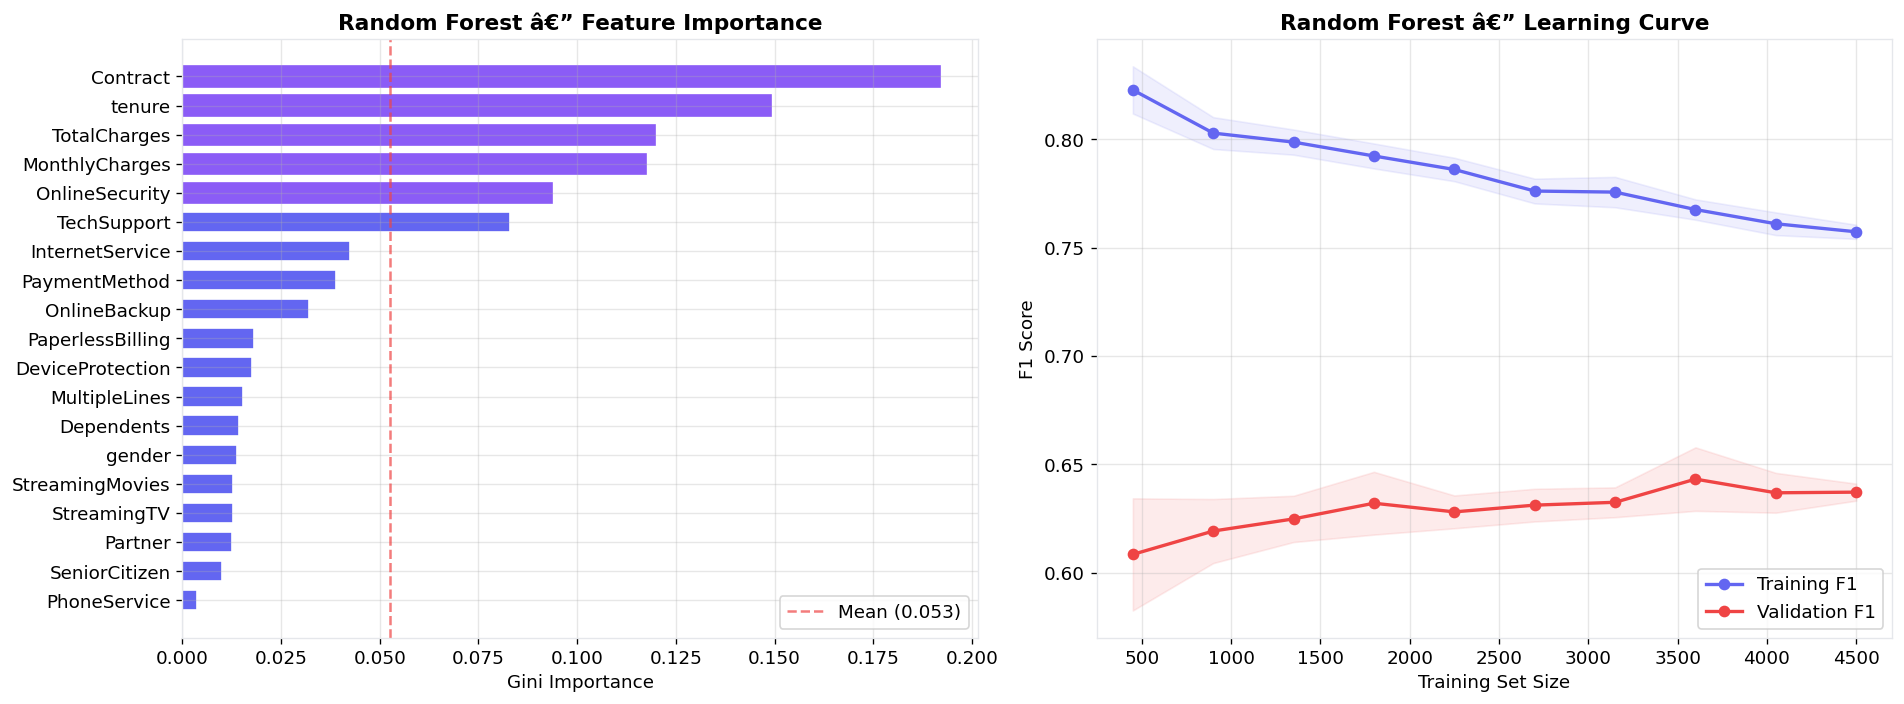

In [13]:
# Feature importance + Learning curve
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature importance
feat_imp_rf = pd.Series(rf_best.feature_importances_, index=X.columns).sort_values(ascending=True)
bars = axes[0].barh(feat_imp_rf.index, feat_imp_rf.values, color=COLORS['primary'],
               edgecolor='white', height=0.7)
for bar in bars[-5:]:
    bar.set_color(COLORS['secondary'])
axes[0].set_title('Random Forest â€” Feature Importance')
axes[0].set_xlabel('Gini Importance')
axes[0].axvline(x=feat_imp_rf.mean(), color=COLORS['danger'], linestyle='--', alpha=0.7,
                label=f'Mean ({feat_imp_rf.mean():.3f})')
axes[0].legend()

# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    rf_best, X_train, y_train, cv=CV, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)
axes[1].plot(train_sizes, train_scores.mean(axis=1), 'o-', color=COLORS['primary'],
             label='Training F1', linewidth=2)
axes[1].fill_between(train_sizes,
                     train_scores.mean(axis=1) - train_scores.std(axis=1),
                     train_scores.mean(axis=1) + train_scores.std(axis=1),
                     alpha=0.1, color=COLORS['primary'])
axes[1].plot(train_sizes, val_scores.mean(axis=1), 'o-', color=COLORS['danger'],
             label='Validation F1', linewidth=2)
axes[1].fill_between(train_sizes,
                     val_scores.mean(axis=1) - val_scores.std(axis=1),
                     val_scores.mean(axis=1) + val_scores.std(axis=1),
                     alpha=0.1, color=COLORS['danger'])
axes[1].set_title('Random Forest â€” Learning Curve')
axes[1].set_xlabel('Training Set Size')
axes[1].set_ylabel('F1 Score')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### 4.2 XGBoost Classifier

In [14]:
# Handle class imbalance with scale_pos_weight
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Class ratio (negative/positive): {scale_pos:.2f}')

# Hyperparameter tuning via GridSearchCV
param_grid_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2]
}

# RandomizedSearchCV (full grid is 12,000+ combos â€” sample 200)
grid_xgb = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos,
        eval_metric='logloss',
        random_state=42
    ),
    param_grid_xgb,
    n_iter=200,
    cv=CV,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
grid_xgb.fit(X_train, y_train)

xgb_model = grid_xgb.best_estimator_
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(f'\nBest parameters: {grid_xgb.best_params_}')
print(f'Best CV F1 score: {grid_xgb.best_score_:.4f}')
print()
print('=== XGBoost (Optimized) ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_xgb):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_xgb):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_xgb):.4f}')
print(f'ROC AUC:   {roc_auc_score(y_test, y_prob_xgb):.4f}')
print(f'Avg Prec:  {average_precision_score(y_test, y_prob_xgb):.4f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=['No Churn', 'Churn']))

Class ratio (negative/positive): 2.76
Fitting 5 folds for each of 200 candidates, totalling 1000 fits

Best parameters: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best CV F1 score: 0.6394

=== XGBoost (Optimized) ===
Accuracy:  0.7377
Precision: 0.5042
Recall:    0.7995
F1 Score:  0.6184
ROC AUC:   0.8390
Avg Prec:  0.6518

              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1033
       Churn       0.50      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.75      1407



In [15]:
# Cross-validation stability check
cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='f1')
print(f'5-Fold CV F1: {cv_scores_xgb.mean():.4f} Â± {cv_scores_xgb.std():.4f}')
print(f'Per fold: {np.round(cv_scores_xgb, 4)}')

5-Fold CV F1: 0.6331 Â± 0.0258
Per fold: [0.6078 0.6613 0.6512 0.5967 0.6487]


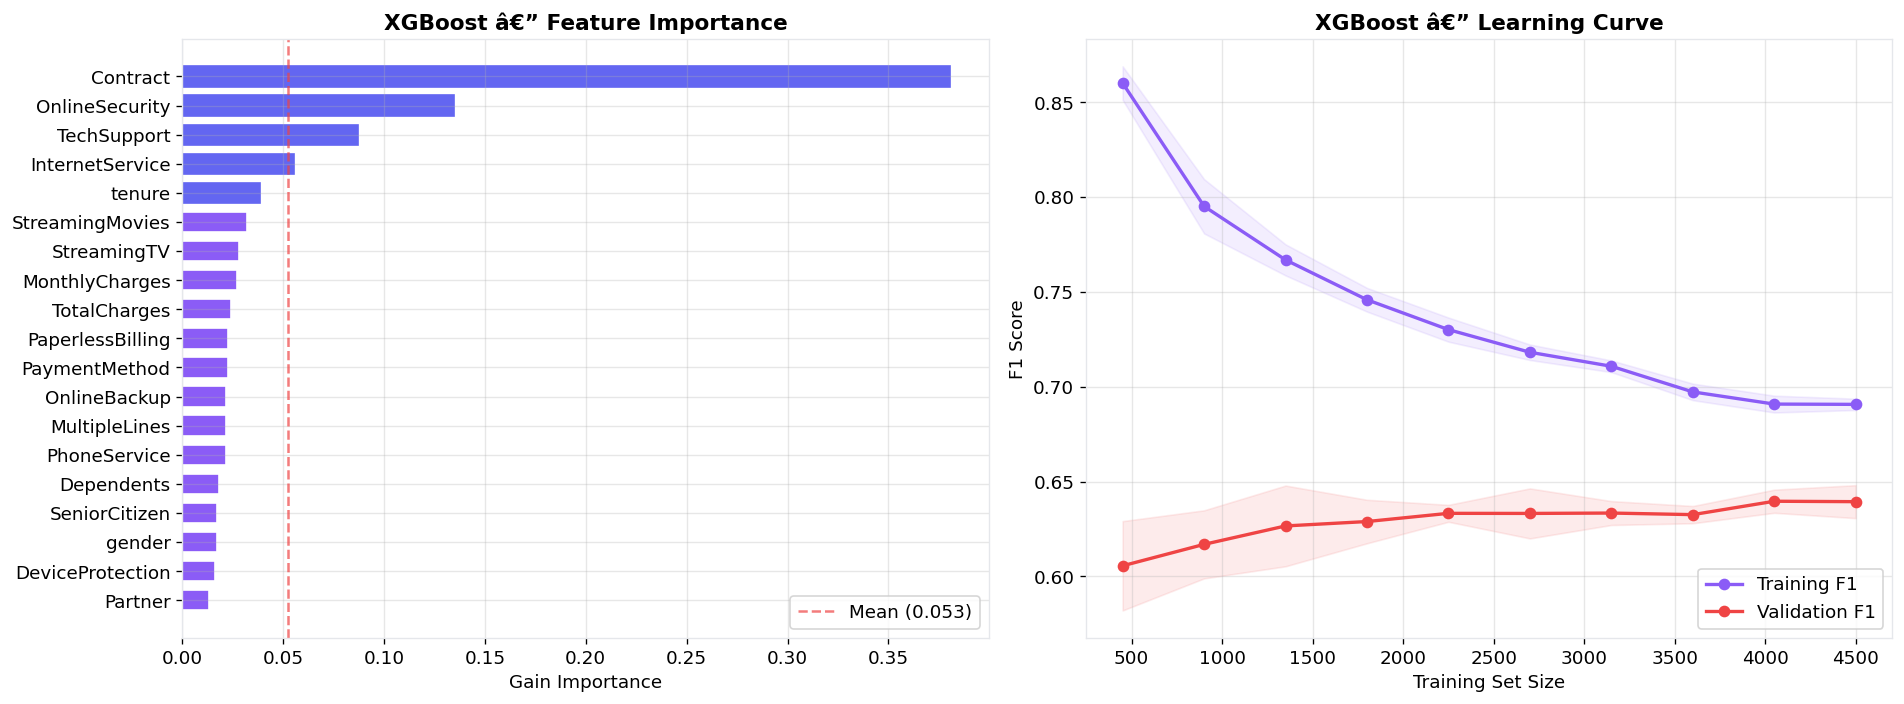

In [16]:
# Feature importance + Learning curve
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature importance
feat_imp_xgb = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=True)
bars = axes[0].barh(feat_imp_xgb.index, feat_imp_xgb.values, color=COLORS['secondary'],
               edgecolor='white', height=0.7)
for bar in bars[-5:]:
    bar.set_color(COLORS['primary'])
axes[0].set_title('XGBoost â€” Feature Importance')
axes[0].set_xlabel('Gain Importance')
axes[0].axvline(x=feat_imp_xgb.mean(), color=COLORS['danger'], linestyle='--', alpha=0.7,
                label=f'Mean ({feat_imp_xgb.mean():.3f})')
axes[0].legend()

# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    xgb_model, X_train, y_train, cv=CV, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)
axes[1].plot(train_sizes, train_scores.mean(axis=1), 'o-', color=COLORS['secondary'],
             label='Training F1', linewidth=2)
axes[1].fill_between(train_sizes,
                     train_scores.mean(axis=1) - train_scores.std(axis=1),
                     train_scores.mean(axis=1) + train_scores.std(axis=1),
                     alpha=0.1, color=COLORS['secondary'])
axes[1].plot(train_sizes, val_scores.mean(axis=1), 'o-', color=COLORS['danger'],
             label='Validation F1', linewidth=2)
axes[1].fill_between(train_sizes,
                     val_scores.mean(axis=1) - val_scores.std(axis=1),
                     val_scores.mean(axis=1) + val_scores.std(axis=1),
                     alpha=0.1, color=COLORS['danger'])
axes[1].set_title('XGBoost â€” Learning Curve')
axes[1].set_xlabel('Training Set Size')
axes[1].set_ylabel('F1 Score')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### 4.3 Support Vector Machine (SVM)

SVM with an RBF kernel finds a non-linear decision boundary in feature space. Because SVMs are
distance-based, scaled features are required. We use `class_weight='balanced'` to mitigate the ~26% / 74%
class imbalance and enable `probability=True` so we can output churn probabilities for the dashboard.


In [17]:
# SVM with RBF kernel — needs scaled inputs and class balancing
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
y_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

print('SVM (RBF) — Test Performance')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_svm):.4f}')
print(f'  Recall   : {recall_score(y_test, y_pred_svm):.4f}')
print(f'  F1 Score : {f1_score(y_test, y_pred_svm):.4f}')
print(f'  ROC AUC  : {roc_auc_score(y_test, y_proba_svm):.4f}')


SVM (RBF) — Test Performance
  Accuracy : 0.7257
  Precision: 0.4896
  Recall   : 0.7540
  F1 Score : 0.5937
  ROC AUC  : 0.8104


In [18]:
# 5-fold CV stability check (uses scaled features)
cv_scores_svm = cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f'SVM CV F1 scores: {cv_scores_svm}')
print(f'  Mean: {cv_scores_svm.mean():.4f}  Std: {cv_scores_svm.std():.4f}')


SVM CV F1 scores: [0.6048906  0.64980027 0.61702128 0.58276334 0.61351351]
  Mean: 0.6136  Std: 0.0217


### 4.4 Supervised Models Comparison

Both models were evaluated under identical conditions:
- Same stratified 80/20 train-test split (`random_state=42`)
- Class imbalance addressed in both (RF: `class_weight`, XGB: `scale_pos_weight`)
- Metrics computed on the same held-out test set

In [20]:
# Comparison table
sup_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Churn)', 'Recall (Churn)', 'F1 Score (Churn)',
               'ROC AUC', 'Avg Precision', 'CV F1 (mean ± std)'],
    'Random Forest': [
        f'{accuracy_score(y_test, y_pred_rf):.4f}',
        f'{precision_score(y_test, y_pred_rf):.4f}',
        f'{recall_score(y_test, y_pred_rf):.4f}',
        f'{f1_score(y_test, y_pred_rf):.4f}',
        f'{roc_auc_score(y_test, y_prob_rf):.4f}',
        f'{average_precision_score(y_test, y_prob_rf):.4f}',
        f'{cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}'
    ],
    'XGBoost': [
        f'{accuracy_score(y_test, y_pred_xgb):.4f}',
        f'{precision_score(y_test, y_pred_xgb):.4f}',
        f'{recall_score(y_test, y_pred_xgb):.4f}',
        f'{f1_score(y_test, y_pred_xgb):.4f}',
        f'{roc_auc_score(y_test, y_prob_xgb):.4f}',
        f'{average_precision_score(y_test, y_prob_xgb):.4f}',
        f'{cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}'
    ],
    'SVM': [
        f'{accuracy_score(y_test, y_pred_svm):.4f}',
        f'{precision_score(y_test, y_pred_svm):.4f}',
        f'{recall_score(y_test, y_pred_svm):.4f}',
        f'{f1_score(y_test, y_pred_svm):.4f}',
        f'{roc_auc_score(y_test, y_proba_svm):.4f}',
        f'{average_precision_score(y_test, y_proba_svm):.4f}',
        f'{cv_scores_svm.mean():.4f} ± {cv_scores_svm.std():.4f}'
    ]
})

print('=' * 75)
print('        SUPERVISED MODELS — PERFORMANCE COMPARISON')
print('=' * 75)
print(sup_results.to_string(index=False))
print('=' * 75)


        SUPERVISED MODELS — PERFORMANCE COMPARISON
            Metric   Random Forest         XGBoost             SVM
          Accuracy          0.7655          0.7377          0.7257
 Precision (Churn)          0.5430          0.5042          0.4896
    Recall (Churn)          0.7433          0.7995          0.7540
  F1 Score (Churn)          0.6275          0.6184          0.5937
           ROC AUC          0.8339          0.8390          0.8104
     Avg Precision          0.6391          0.6518          0.6021
CV F1 (mean ± std) 0.6277 ± 0.0269 0.6331 ± 0.0258 0.6136 ± 0.0217


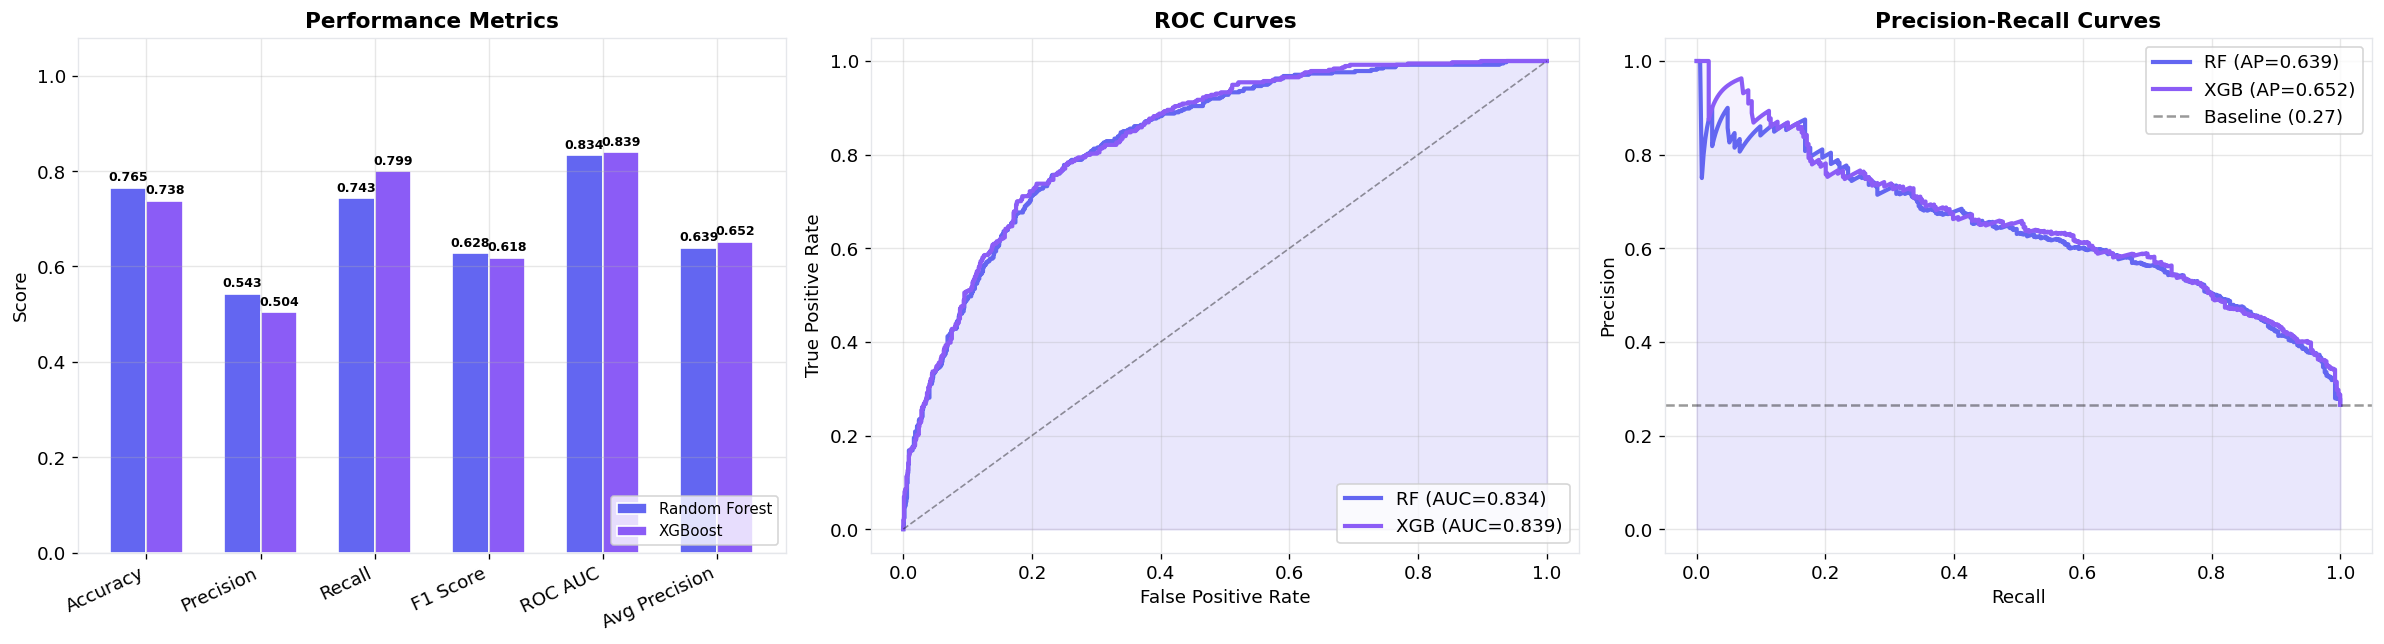

In [21]:
# Metric comparison + ROC curves + Precision-Recall curves
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'Avg Precision']
rf_scores = [
    accuracy_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf),
    roc_auc_score(y_test, y_prob_rf), average_precision_score(y_test, y_prob_rf)
]
xgb_scores = [
    accuracy_score(y_test, y_pred_xgb), precision_score(y_test, y_pred_xgb),
    recall_score(y_test, y_pred_xgb), f1_score(y_test, y_pred_xgb),
    roc_auc_score(y_test, y_prob_xgb), average_precision_score(y_test, y_prob_xgb)
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# --- Bar chart ---
x = np.arange(len(metric_names))
w = 0.32
b1 = axes[0].bar(x - w/2, rf_scores, w, label='Random Forest', color=COLORS['primary'], edgecolor='white')
b2 = axes[0].bar(x + w/2, xgb_scores, w, label='XGBoost', color=COLORS['secondary'], edgecolor='white')
for bars in [b1, b2]:
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                     f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names, rotation=25, ha='right')
axes[0].set_ylim(0, 1.08)
axes[0].set_ylabel('Score')
axes[0].set_title('Performance Metrics')
axes[0].legend(loc='lower right', fontsize=9)

# --- ROC Curves ---
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
axes[1].plot(fpr_rf, tpr_rf, color=COLORS['primary'], linewidth=2.5,
             label=f'RF (AUC={roc_auc_score(y_test, y_prob_rf):.3f})')
axes[1].plot(fpr_xgb, tpr_xgb, color=COLORS['secondary'], linewidth=2.5,
             label=f'XGB (AUC={roc_auc_score(y_test, y_prob_xgb):.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=1)
axes[1].fill_between(fpr_rf, tpr_rf, alpha=0.08, color=COLORS['primary'])
axes[1].fill_between(fpr_xgb, tpr_xgb, alpha=0.08, color=COLORS['secondary'])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend(loc='lower right')

# --- Precision-Recall Curves (more informative for imbalanced data) ---
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
axes[2].plot(rec_rf, prec_rf, color=COLORS['primary'], linewidth=2.5,
             label=f'RF (AP={average_precision_score(y_test, y_prob_rf):.3f})')
axes[2].plot(rec_xgb, prec_xgb, color=COLORS['secondary'], linewidth=2.5,
             label=f'XGB (AP={average_precision_score(y_test, y_prob_xgb):.3f})')
baseline = y_test.mean()
axes[2].axhline(y=baseline, color='k', linestyle='--', alpha=0.4, label=f'Baseline ({baseline:.2f})')
axes[2].fill_between(rec_rf, prec_rf, alpha=0.08, color=COLORS['primary'])
axes[2].fill_between(rec_xgb, prec_xgb, alpha=0.08, color=COLORS['secondary'])
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curves')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

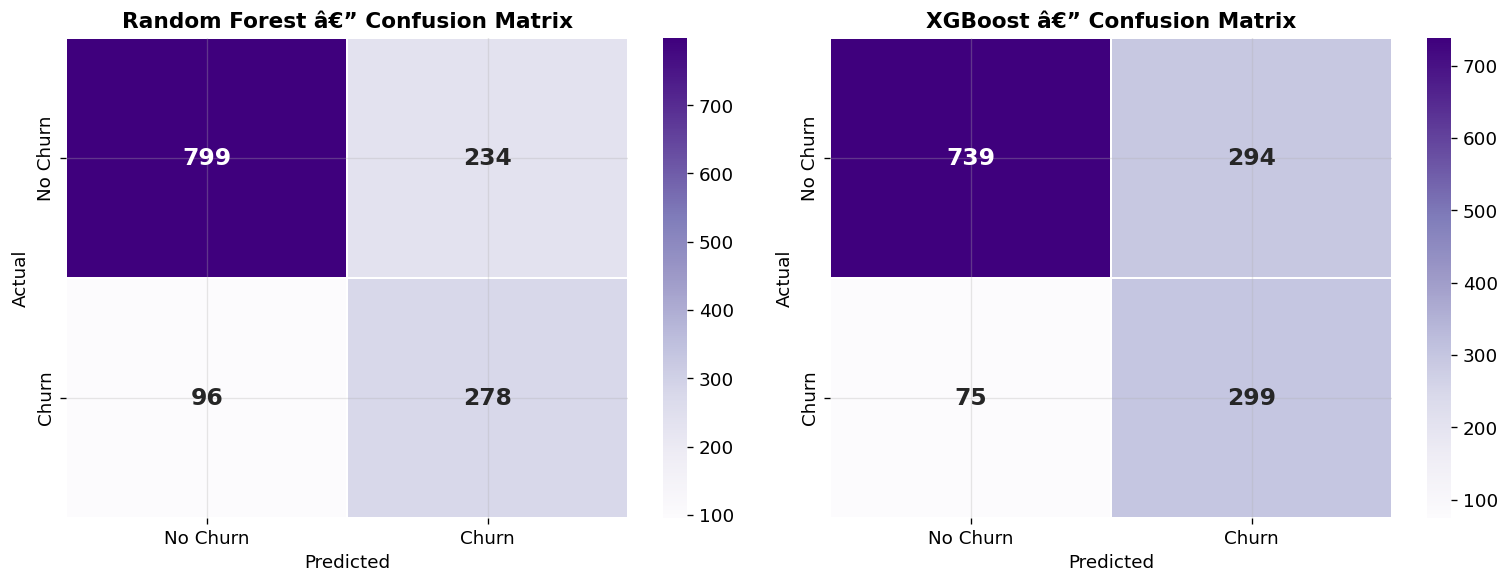

In [22]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, preds, title in [
    (axes[0], y_pred_rf, 'Random Forest'),
    (axes[1], y_pred_xgb, 'XGBoost')
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'],
                linewidths=1, linecolor='white', annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(f'{title} â€” Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

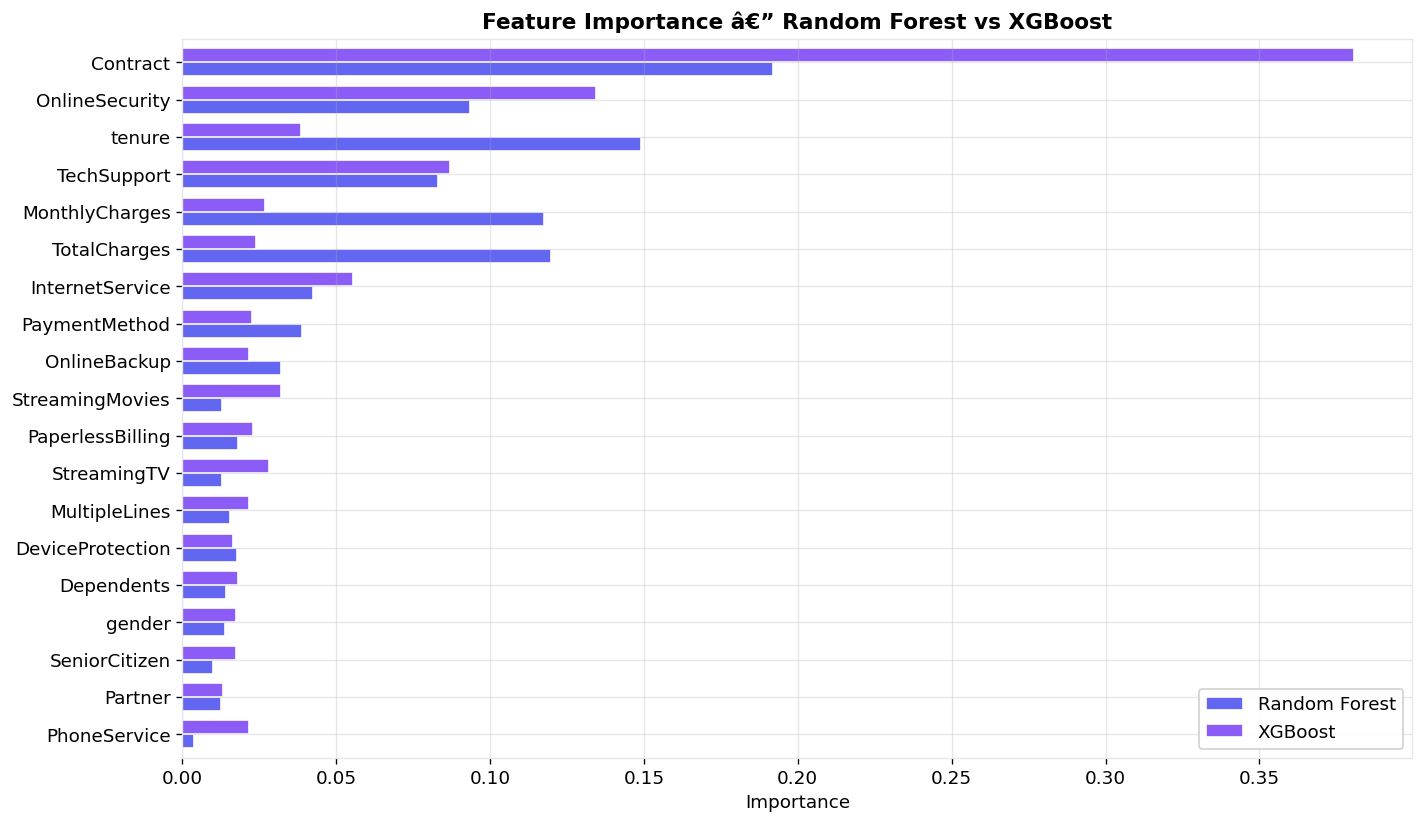

In [23]:
# Feature importance comparison (side by side)
imp_df = pd.DataFrame({
    'Random Forest': rf_best.feature_importances_,
    'XGBoost': xgb_model.feature_importances_
}, index=X.columns)

# Sort by average importance
imp_df = imp_df.loc[imp_df.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(12, 7))
imp_df.plot(kind='barh', ax=ax, color=[COLORS['primary'], COLORS['secondary']],
            edgecolor='white', width=0.75)
ax.set_title('Feature Importance â€” Random Forest vs XGBoost')
ax.set_xlabel('Importance')
ax.legend(loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.show()

**Key Observations â€” Supervised Models:**

1. **ROC AUC** is the most reliable metric given the class imbalance (~26% churn). A higher AUC indicates better ability to discriminate churners from non-churners across all decision thresholds.
2. **Recall** is business-critical: it measures how many actual churners the model catches. Missing a churner means losing a customer without intervention.
3. **Cross-validation F1** scores show model stability â€” lower standard deviation means more consistent performance.
4. Both models agree on the most important features (e.g., tenure, contract type, monthly charges), which adds confidence to the findings.
5. The confusion matrices reveal the specific error patterns: false negatives (missed churners) vs false positives (false alarms).

### 4.5 Objective Best Supervised Model

The three supervised models share identical evaluation conditions (same train/test split, same class-balancing, same cross-validation), so they can be ranked directly on a common metric stack. The chosen tie-breaker hierarchy reflects the business cost structure of customer churn:

1. **ROC AUC** — primary metric. Threshold-independent and robust to the ~26.5% class imbalance.
2. **Recall (churn class)** — secondary. Missing a churner = lost customer; the cost of a false negative dominates the cost of a false positive.
3. **Cross-validated F1 (mean and std)** — tertiary. Catches models that look good on a single test set but generalise poorly.


In [ ]:
# Objective ranking: rank each model on the IDENTICAL metric stack
sup_objective = pd.DataFrame({
    'Model':          ['Random Forest', 'XGBoost', 'SVM (RBF)'],
    'Accuracy':       [accuracy_score(y_test, y_pred_rf),
                       accuracy_score(y_test, y_pred_xgb),
                       accuracy_score(y_test, y_pred_svm)],
    'Precision':      [precision_score(y_test, y_pred_rf),
                       precision_score(y_test, y_pred_xgb),
                       precision_score(y_test, y_pred_svm)],
    'Recall':         [recall_score(y_test, y_pred_rf),
                       recall_score(y_test, y_pred_xgb),
                       recall_score(y_test, y_pred_svm)],
    'F1':             [f1_score(y_test, y_pred_rf),
                       f1_score(y_test, y_pred_xgb),
                       f1_score(y_test, y_pred_svm)],
    'ROC AUC':        [roc_auc_score(y_test, y_prob_rf),
                       roc_auc_score(y_test, y_prob_xgb),
                       roc_auc_score(y_test, y_proba_svm)],
    'Avg Precision':  [average_precision_score(y_test, y_prob_rf),
                       average_precision_score(y_test, y_prob_xgb),
                       average_precision_score(y_test, y_proba_svm)],
    'CV F1 (mean)':   [cv_scores_rf.mean(), cv_scores_xgb.mean(), cv_scores_svm.mean()],
    'CV F1 (std)':    [cv_scores_rf.std(),  cv_scores_xgb.std(),  cv_scores_svm.std()],
}).round(4)

# Rank: ROC AUC desc -> Recall desc -> CV-F1 mean desc
ranking = sup_objective.sort_values(
    ['ROC AUC', 'Recall', 'CV F1 (mean)'],
    ascending=[False, False, False]
).reset_index(drop=True)
ranking.insert(0, 'Rank', ranking.index + 1)

print('Objective Supervised Ranking (tie-break: AUC > Recall > CV F1)')
print('=' * 95)
print(ranking.to_string(index=False))

winner_sup = ranking.iloc[0]['Model']
print(f'\n>>> Best Supervised: {winner_sup} <<<')
print(f'    ROC AUC       = {ranking.iloc[0]["ROC AUC"]:.4f}')
print(f'    Recall        = {ranking.iloc[0]["Recall"]:.4f}')
print(f'    Avg Precision = {ranking.iloc[0]["Avg Precision"]:.4f}')
print(f'    CV F1         = {ranking.iloc[0]["CV F1 (mean)"]:.4f} ± {ranking.iloc[0]["CV F1 (std)"]:.4f}')


<a id='5'></a>
## 5. Unsupervised Learning

Unsupervised models do **not** use the churn labels for training. Labels are only used *after* clustering to evaluate whether discovered segments correlate with churn behavior.

**Evaluation metrics:**
| Metric | Range | Better |
|--------|-------|--------|
| Silhouette Score | [-1, 1] | Higher |
| Davies-Bouldin Index | [0, âˆž) | Lower |
| Calinski-Harabasz | [0, âˆž) | Higher |

### 5.1 Gaussian Mixture Model (GMM)

Rather than guessing the number of components, we use the **Bayesian Information Criterion (BIC)** to find the optimal value.

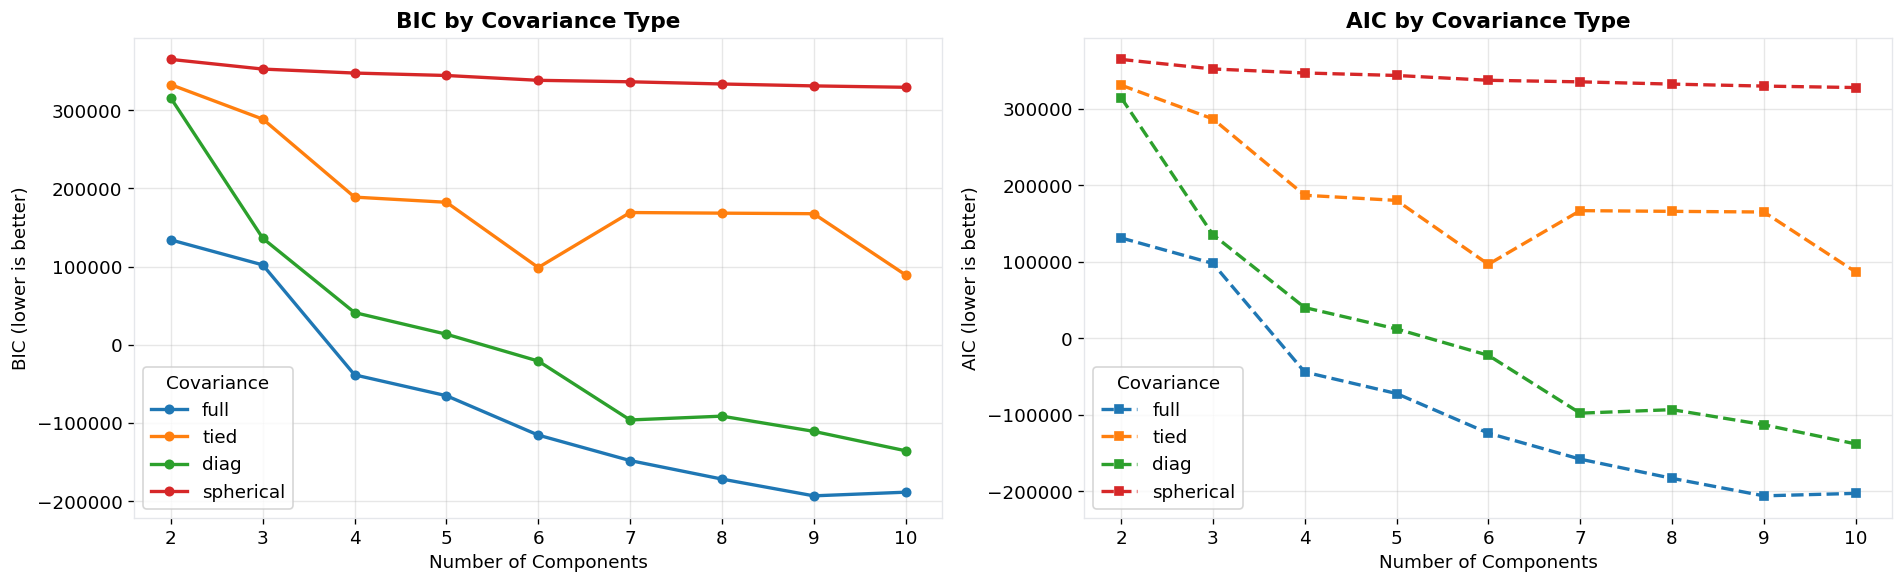

Optimal config (BIC): n_components=9, covariance_type=full


In [26]:
# BIC / AIC component selection across covariance types
n_range = range(2, 11)
cov_types = ['full', 'tied', 'diag', 'spherical']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

best_bic = np.inf
best_config = {}

for cov_type in cov_types:
    bics, aics = [], []
    for n in n_range:
        gmm_tmp = GaussianMixture(n_components=n, covariance_type=cov_type, random_state=42, n_init=3)
        gmm_tmp.fit(X_scaled)
        bics.append(gmm_tmp.bic(X_scaled))
        aics.append(gmm_tmp.aic(X_scaled))

        if bics[-1] < best_bic:
            best_bic = bics[-1]
            best_config = {'n_components': n, 'covariance_type': cov_type}

    axes[0].plot(list(n_range), bics, 'o-', linewidth=2, markersize=5, label=cov_type)
    axes[1].plot(list(n_range), aics, 's--', linewidth=2, markersize=5, label=cov_type)

axes[0].set_title('BIC by Covariance Type')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('BIC (lower is better)')
axes[0].set_xticks(list(n_range))
axes[0].legend(title='Covariance')

axes[1].set_title('AIC by Covariance Type')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('AIC (lower is better)')
axes[1].set_xticks(list(n_range))
axes[1].legend(title='Covariance')

plt.tight_layout()
plt.show()

best_n_gmm = best_config['n_components']
best_cov = best_config['covariance_type']
print(f'Optimal config (BIC): n_components={best_n_gmm}, covariance_type={best_cov}')

In [27]:
# Fit GMM with optimal config from BIC search
gmm = GaussianMixture(
    n_components=best_n_gmm,
    covariance_type=best_cov,
    random_state=42,
    n_init=10,
    max_iter=300
)
gmm.fit(X_scaled)
gmm_labels = gmm.predict(X_scaled)
gmm_probs = gmm.predict_proba(X_scaled)

gmm_sil = silhouette_score(X_scaled, gmm_labels)
gmm_dbi = davies_bouldin_score(X_scaled, gmm_labels)
gmm_chi = calinski_harabasz_score(X_scaled, gmm_labels)

print(f'=== GMM (n_components={best_n_gmm}, covariance={best_cov}) ===')
print(f'Silhouette Score:       {gmm_sil:>8.4f}  (higher is better, range [-1, 1])')
print(f'Davies-Bouldin Index:   {gmm_dbi:>8.4f}  (lower is better)')
print(f'Calinski-Harabasz:      {gmm_chi:>8.2f}  (higher is better)')
print(f'Log-Likelihood:         {gmm.score(X_scaled):>8.4f}')
print(f'Converged: {gmm.converged_} in {gmm.n_iter_} iterations')
print(f'\nCluster sizes:')
for i in range(best_n_gmm):
    count = (gmm_labels == i).sum()
    pct = count / len(gmm_labels) * 100
    churn_rate = y[gmm_labels == i].mean() * 100
    print(f'  Cluster {i}: {count:>5,} ({pct:>5.1f}%) â€” churn rate: {churn_rate:.1f}%')

print(f'\nCluster vs Actual Churn:')
ct = pd.crosstab(gmm_labels, y, margins=True, margins_name='Total')
ct.columns = ['No Churn', 'Churn', 'Total']
ct.index.name = 'Cluster'
print(ct)

=== GMM (n_components=9, covariance=full) ===
Silhouette Score:         0.0814  (higher is better, range [-1, 1])
Davies-Bouldin Index:     2.6482  (lower is better)
Calinski-Harabasz:        471.13  (higher is better)
Log-Likelihood:          14.9243
Converged: True in 14 iterations

Cluster sizes:
  Cluster 0:   634 (  9.0%) â€” churn rate: 4.4%
  Cluster 1: 1,105 ( 15.7%) â€” churn rate: 39.7%
  Cluster 2: 1,096 ( 15.6%) â€” churn rate: 24.3%
  Cluster 3:   747 ( 10.6%) â€” churn rate: 46.1%
  Cluster 4:   802 ( 11.4%) â€” churn rate: 10.6%
  Cluster 5:   332 (  4.7%) â€” churn rate: 5.4%
  Cluster 6: 1,082 ( 15.4%) â€” churn rate: 41.8%
  Cluster 7:   554 (  7.9%) â€” churn rate: 12.1%
  Cluster 8:   680 (  9.7%) â€” churn rate: 25.0%

Cluster vs Actual Churn:
         No Churn  Churn  Total
Cluster                        
0             606     28    634
1             666    439   1105
2             830    266   1096
3             403    344    747
4             717     85    802
5

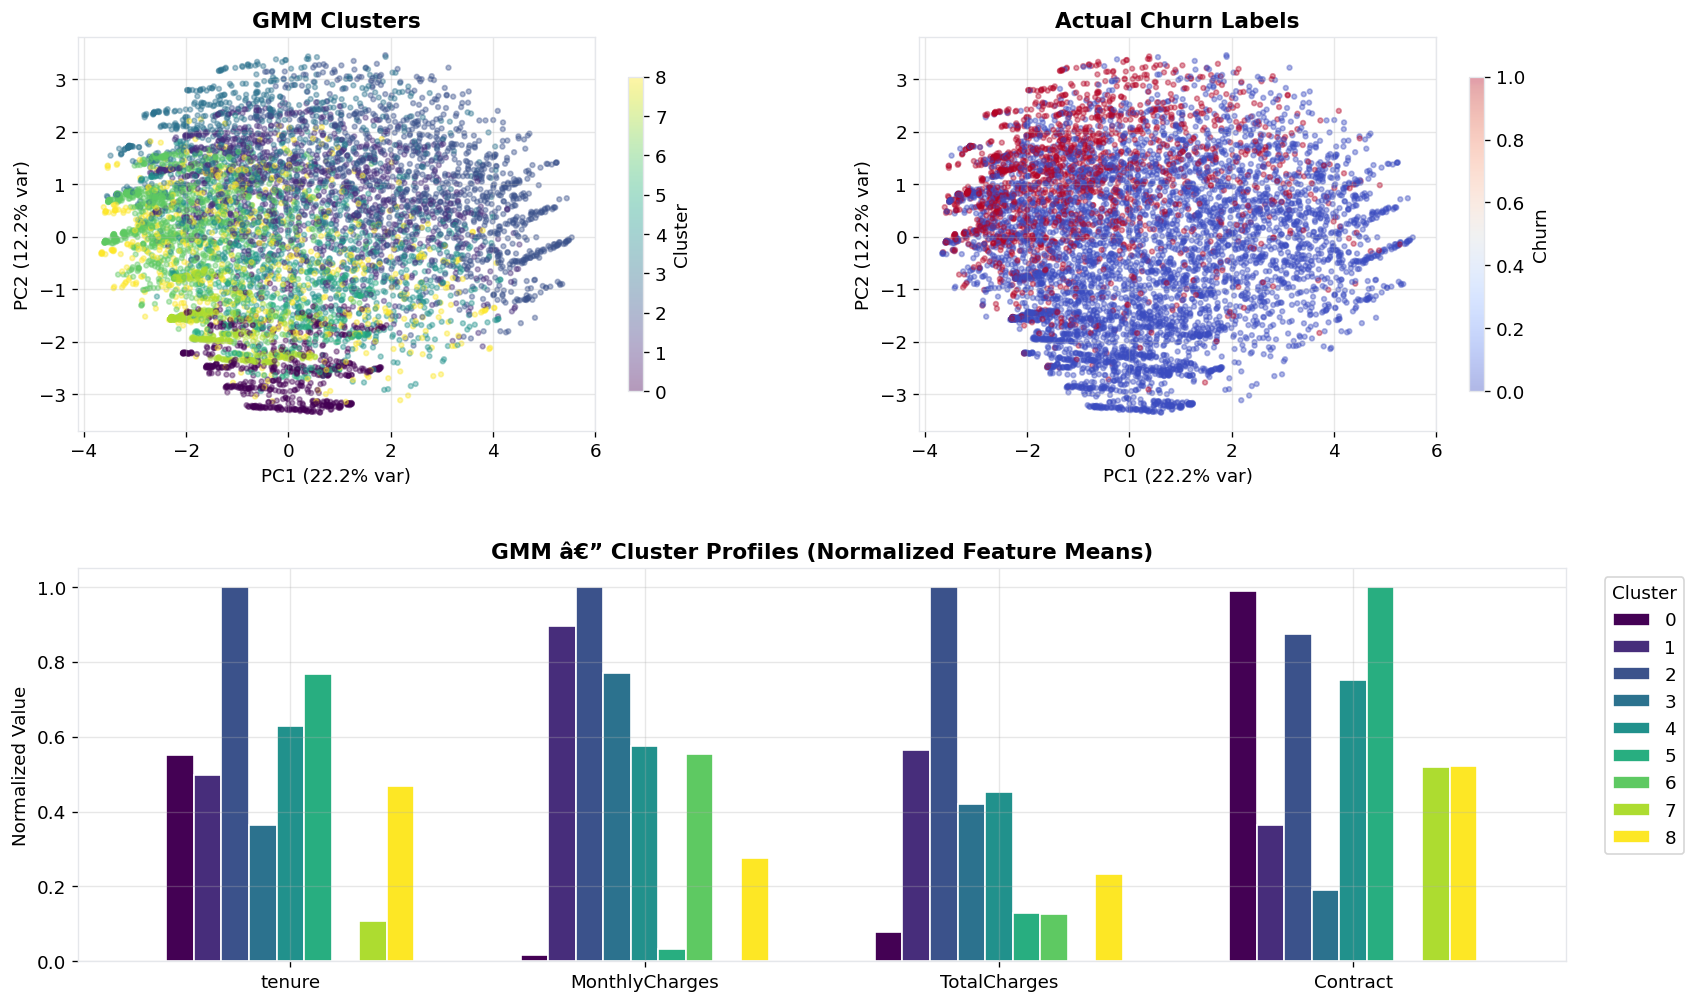

In [28]:
# GMM: PCA visualization + Cluster profiling
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

# PCA scatter â€” GMM clusters
ax1 = fig.add_subplot(gs[0, 0])
sc1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap='viridis', alpha=0.4, s=8)
ax1.set_title('GMM Clusters')
ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var)')
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var)')
plt.colorbar(sc1, ax=ax1, label='Cluster', shrink=0.8)

# PCA scatter â€” actual labels
ax2 = fig.add_subplot(gs[0, 1])
sc2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.4, s=8)
ax2.set_title('Actual Churn Labels')
ax2.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var)')
ax2.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var)')
plt.colorbar(sc2, ax=ax2, label='Churn', shrink=0.8)

# Cluster profiles â€” key numeric features
ax3 = fig.add_subplot(gs[1, :])
profile_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract']
cluster_profiles = df_encoded.copy()
cluster_profiles['Cluster'] = gmm_labels
profile_data = cluster_profiles.groupby('Cluster')[profile_features].mean()

profile_norm = (profile_data - profile_data.min()) / (profile_data.max() - profile_data.min())
profile_norm.T.plot(kind='bar', ax=ax3, colormap='viridis', edgecolor='white', width=0.7)
ax3.set_title('GMM â€” Cluster Profiles (Normalized Feature Means)')
ax3.set_ylabel('Normalized Value')
ax3.set_xticklabels(profile_features, rotation=0)
ax3.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 5.2 DBSCAN

DBSCAN struggles in high-dimensional spaces due to the **curse of dimensionality** (distances become uniformly large). To address this:
1. **PCA** reduces dimensions before clustering
2. A **k-distance plot** empirically selects the `eps` parameter

In [30]:
# Dimensionality reduction for DBSCAN
pca_db = PCA(n_components=5, random_state=42)
X_pca_db = pca_db.fit_transform(X_scaled)

print(f'PCA: {X_scaled.shape[1]} features â†’ {X_pca_db.shape[1]} components')
print(f'Explained variance: {pca_db.explained_variance_ratio_.sum():.1%}')
for i, var in enumerate(pca_db.explained_variance_ratio_):
    print(f'  PC{i+1}: {var:.1%}')

PCA: 19 features â†’ 5 components
Explained variance: 54.4%
  PC1: 22.2%
  PC2: 12.2%
  PC3: 7.9%
  PC4: 6.4%
  PC5: 5.7%


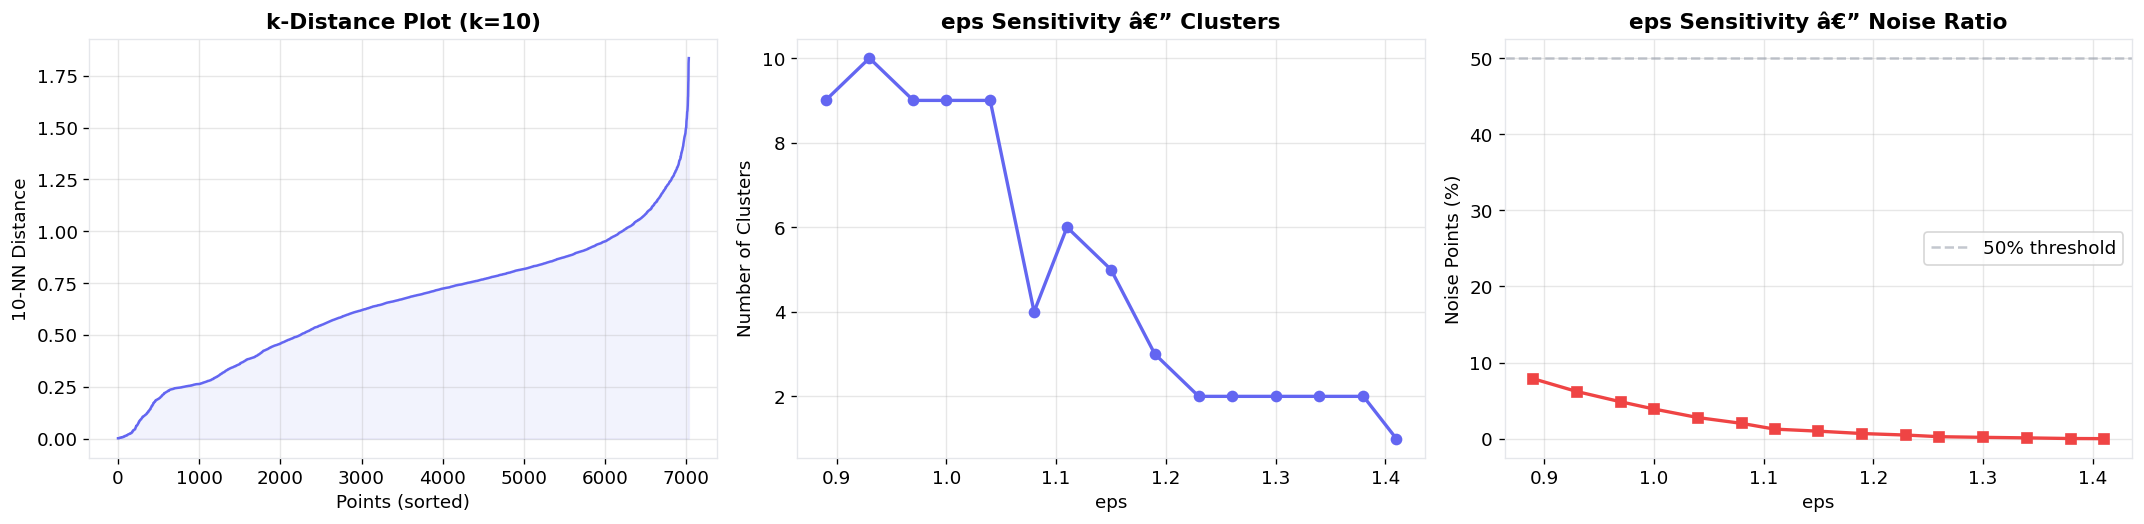

eps sensitivity scan complete.
Selected eps: 0.89 | min_samples: 10

Full scan results:
 eps  clusters  noise  noise_pct
0.89         9    555   7.892491
0.93        10    436   6.200228
0.97         9    341   4.849261
1.00         9    275   3.910694
1.04         9    196   2.787258
1.08         4    142   2.019340
1.11         6     89   1.265643
1.15         5     70   0.995449
1.19         3     48   0.682594
1.23         2     34   0.483504
1.26         2     19   0.270193
1.30         2     13   0.184869
1.34         2      8   0.113766
1.38         2      2   0.028441
1.41         1      1   0.014221


In [31]:
# k-distance plot + eps sensitivity analysis
k = 10
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_pca_db)
distances, _ = nn.kneighbors(X_pca_db)
k_distances = np.sort(distances[:, -1])

# Test multiple eps values
eps_candidates = np.round(np.linspace(
    np.percentile(k_distances, 80),
    np.percentile(k_distances, 99),
    15
), 2)

eps_results = []
for eps_test in eps_candidates:
    db_tmp = DBSCAN(eps=eps_test, min_samples=k).fit_predict(X_pca_db)
    n_clust = len(set(db_tmp)) - (1 if -1 in db_tmp else 0)
    n_noi = (db_tmp == -1).sum()
    noise_p = n_noi / len(db_tmp) * 100
    eps_results.append({
        'eps': eps_test, 'clusters': n_clust,
        'noise': n_noi, 'noise_pct': noise_p
    })

eps_df = pd.DataFrame(eps_results)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# k-distance plot
axes[0].plot(k_distances, color=COLORS['primary'], linewidth=1.5)
axes[0].fill_between(range(len(k_distances)), k_distances, alpha=0.08, color=COLORS['primary'])
axes[0].set_xlabel('Points (sorted)')
axes[0].set_ylabel(f'{k}-NN Distance')
axes[0].set_title(f'k-Distance Plot (k={k})')

# eps vs clusters
axes[1].plot(eps_df['eps'], eps_df['clusters'], 'o-', color=COLORS['primary'], linewidth=2, markersize=6)
axes[1].set_xlabel('eps')
axes[1].set_ylabel('Number of Clusters')
axes[1].set_title('eps Sensitivity â€” Clusters')

# eps vs noise
axes[2].plot(eps_df['eps'], eps_df['noise_pct'], 's-', color=COLORS['danger'], linewidth=2, markersize=6)
axes[2].set_xlabel('eps')
axes[2].set_ylabel('Noise Points (%)')
axes[2].set_title('eps Sensitivity â€” Noise Ratio')
axes[2].axhline(y=50, color=COLORS['muted'], linestyle='--', alpha=0.6, label='50% threshold')
axes[2].legend()

plt.tight_layout()
plt.show()

# Select eps: look for reasonable cluster count (2â€“10) with noise < 30%
reasonable = eps_df[(eps_df['clusters'] >= 2) & (eps_df['clusters'] <= 10) & (eps_df['noise_pct'] < 30)]
if len(reasonable) > 0:
    eps_val = reasonable.iloc[0]['eps']
else:
    eps_val = round(np.percentile(k_distances, 95), 2)

print(f'eps sensitivity scan complete.')
print(f'Selected eps: {eps_val} | min_samples: {k}')
print(f'\nFull scan results:')
print(eps_df.to_string(index=False))

In [34]:
# Fit DBSCAN
dbscan = DBSCAN(eps=eps_val, min_samples=k)
db_labels = dbscan.fit_predict(X_pca_db)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
noise_pct = n_noise / len(db_labels) * 100
valid_mask = db_labels != -1

print(f'=== DBSCAN (eps={eps_val}, min_samples={k}) ===')
print(f'Clusters found: {n_clusters_db}')
print(f'Noise points:   {n_noise:,} ({noise_pct:.1f}%)')
print(f'\nCluster sizes:')
for label in sorted(set(db_labels)):
    count = (db_labels == label).sum()
    pct = count / len(db_labels) * 100
    name = 'Noise' if label == -1 else f'Cluster {label}'
    print(f'  {name}: {count:>5,} ({pct:>5.1f}%)')

# Evaluation
n_valid_clusters = len(set(db_labels[valid_mask]))
if n_valid_clusters > 1:
    db_sil = silhouette_score(X_pca_db[valid_mask], db_labels[valid_mask])
    db_dbi = davies_bouldin_score(X_pca_db[valid_mask], db_labels[valid_mask])
    db_chi = calinski_harabasz_score(X_pca_db[valid_mask], db_labels[valid_mask])
    print(f'\nSilhouette Score:       {db_sil:>8.4f}  (higher is better)')
    print(f'Davies-Bouldin Index:   {db_dbi:>8.4f}  (lower is better)')
    print(f'Calinski-Harabasz:      {db_chi:>8.2f}  (higher is better)')
else:
    db_sil, db_dbi, db_chi = None, None, None
    print('\nNot enough valid clusters for evaluation metrics.')

print(f'\nCluster vs Actual Churn (excluding noise):')
ct_db = pd.crosstab(db_labels[valid_mask], y[valid_mask], margins=True, margins_name='Total')
ct_db.columns = ['No Churn', 'Churn', 'Total']
ct_db.index.name = 'Cluster'
print(ct_db)

=== DBSCAN (eps=0.89, min_samples=10) ===
Clusters found: 9
Noise points:   555 (7.9%)

Cluster sizes:
  Noise:   555 (  7.9%)
  Cluster 0: 5,798 ( 82.5%)
  Cluster 1:   228 (  3.2%)
  Cluster 2:   329 (  4.7%)
  Cluster 3:    27 (  0.4%)
  Cluster 4:    28 (  0.4%)
  Cluster 5:    35 (  0.5%)
  Cluster 6:     7 (  0.1%)
  Cluster 7:    14 (  0.2%)
  Cluster 8:    11 (  0.2%)

Silhouette Score:        -0.1625  (higher is better)
Davies-Bouldin Index:     1.2891  (lower is better)
Calinski-Harabasz:        105.29  (higher is better)

Cluster vs Actual Churn (excluding noise):
         No Churn  Churn  Total
Cluster                        
0            4146   1652   5798
1             132     96    228
2             312     17    329
3              20      7     27
4              18     10     28
5              34      1     35
6               7      0      7
7               7      7     14
8              11      0     11
Total        4687   1790   6477


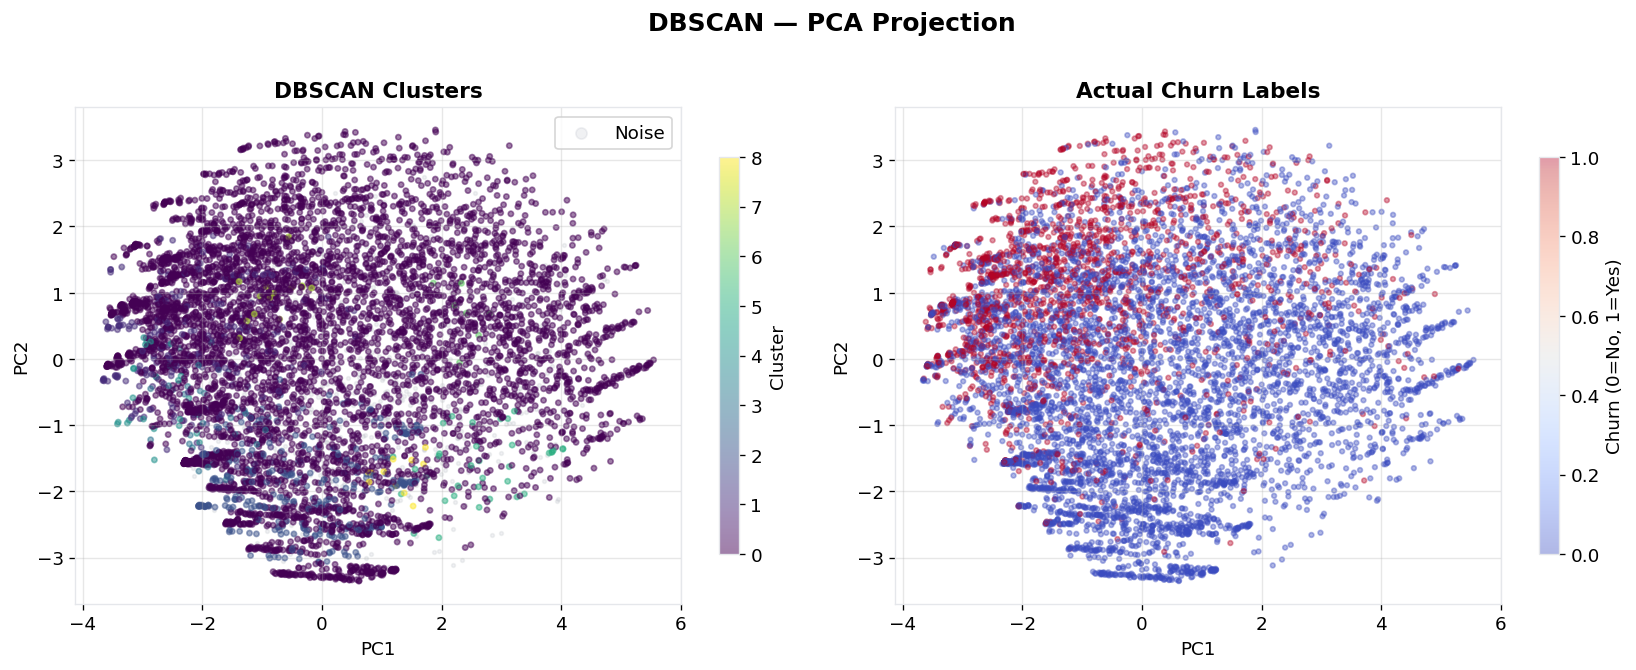

In [35]:
# DBSCAN PCA visualization
X_pca_2d = PCA(n_components=2).fit_transform(X_scaled)

valid_mask = db_labels != -1

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Noise points in grey, clusters in viridis
axes[0].scatter(X_pca_2d[db_labels == -1, 0], X_pca_2d[db_labels == -1, 1],
                c=COLORS['muted'], alpha=0.15, s=5, label='Noise')
if valid_mask.any():
    sc1 = axes[0].scatter(X_pca_2d[valid_mask, 0], X_pca_2d[valid_mask, 1],
                          c=db_labels[valid_mask], cmap='viridis', alpha=0.5, s=10)
    plt.colorbar(sc1, ax=axes[0], label='Cluster', shrink=0.8)
axes[0].legend(markerscale=3, loc='upper right')
axes[0].set_title('DBSCAN Clusters')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

sc2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='coolwarm', alpha=0.4, s=8)
axes[1].set_title('Actual Churn Labels')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(sc2, ax=axes[1], label='Churn (0=No, 1=Yes)', shrink=0.8)

plt.suptitle('DBSCAN — PCA Projection', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 5.3 K-Means Clustering

K-Means partitions customers into *k* spherical clusters by minimising within-cluster variance. Unlike GMM (probabilistic, soft assignments) and DBSCAN (density-based, variable cluster shapes), K-Means assumes equal-variance Gaussian-like blobs and produces hard assignments.

We select *k* objectively using the **silhouette score** over a sweep of `k = 2..10`, then refit at the chosen *k*. The same standardised feature matrix `X_scaled` used by GMM is reused here so all three clustering methods are evaluated on identical input space — the comparison in §5.4 then ranks them on the **same metric stack** (silhouette, Davies-Bouldin, Calinski-Harabasz) rather than method-specific scores.


In [ ]:
# Silhouette + inertia sweep over k = 2..10 to pick K objectively
from sklearn.cluster import KMeans

km_results = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    km_results.append({'k': k, 'silhouette': sil, 'inertia': km.inertia_})
    print(f'  k={k}: silhouette={sil:.4f}, inertia={km.inertia_:.1f}')

km_results = pd.DataFrame(km_results)
best_k_km = int(km_results.loc[km_results['silhouette'].idxmax(), 'k'])
print(f'\nBest K (max silhouette): {best_k_km}')

# Visualise elbow + silhouette
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(km_results['k'], km_results['inertia'], 'o-', color=COLORS['primary'], lw=2)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia (lower is better)')
axes[0].set_title('K-Means Elbow')
axes[0].grid(alpha=0.3)

axes[1].plot(km_results['k'], km_results['silhouette'], 'o-', color=COLORS['secondary'], lw=2)
axes[1].axvline(best_k_km, color=COLORS['danger'], linestyle='--', alpha=0.6, label=f'Best k={best_k_km}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score (higher is better)')
axes[1].set_title('K-Means Silhouette Sweep')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


In [ ]:
# Fit K-Means at chosen k
kmeans = KMeans(n_clusters=best_k_km, n_init=10, random_state=42)
km_labels = kmeans.fit_predict(X_scaled)

print(f'=== K-Means (k={best_k_km}) ===')
print(f'Silhouette:        {silhouette_score(X_scaled, km_labels):.4f}  (higher is better)')
print(f'Davies-Bouldin:    {davies_bouldin_score(X_scaled, km_labels):.4f}  (lower is better)')
print(f'Calinski-Harabasz: {calinski_harabasz_score(X_scaled, km_labels):.4f}  (higher is better)')
print(f'Inertia:           {kmeans.inertia_:.1f}')

print('\nCluster sizes:')
for cid in sorted(set(km_labels)):
    mask = km_labels == cid
    cr = y[mask].mean() * 100
    print(f'  Cluster {cid}: {mask.sum():,} ({mask.sum()/len(km_labels)*100:.1f}%) churn rate: {cr:.1f}%')

km_ct = pd.crosstab(km_labels, y)
km_ct.columns = ['No Churn', 'Churn']
km_ct['Total'] = km_ct.sum(axis=1)
print('\nCluster vs Actual Churn:')
print(km_ct)


In [ ]:
# K-Means PCA visualisation
X_pca_2d_km = PCA(n_components=2).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sc1 = axes[0].scatter(X_pca_2d_km[:, 0], X_pca_2d_km[:, 1],
                      c=km_labels, cmap='viridis', alpha=0.5, s=10)
# Plot centroids in original feature space → project to 2D PCA
centroids_pca = PCA(n_components=2).fit(X_scaled).transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                marker='X', s=180, c='red', edgecolors='white', linewidths=2, label='Centroids')
plt.colorbar(sc1, ax=axes[0], label='Cluster', shrink=0.8)
axes[0].legend(); axes[0].set_title(f'K-Means Clusters (k={best_k_km})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

sc2 = axes[1].scatter(X_pca_2d_km[:, 0], X_pca_2d_km[:, 1], c=y, cmap='coolwarm', alpha=0.4, s=8)
axes[1].set_title('Actual Churn Labels')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.colorbar(sc2, ax=axes[1], label='Churn (0=No, 1=Yes)', shrink=0.8)

plt.suptitle('K-Means — PCA Projection', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


### 5.4 Unsupervised Models Comparison

In [ ]:
# Unified comparison - IDENTICAL conditions for all 3 unsupervised models:
#   - same feature space (X_scaled, full 19-dim) for metric computation
#   - same row set (DBSCAN noise treated as its own cluster -1, NOT excluded)
#   - same metric stack (every metric is defined for every method - no N/A)
# Cluster *fitting* still happens in each model's natural space (DBSCAN uses PCA-reduced
# X_pca_db internally), but the resulting labels are scored on the shared X_scaled space.

y_arr = np.asarray(y)

def cluster_churn_range(labels, y_arr):
    rates = [float(y_arr[labels == c].mean())
             for c in np.unique(labels) if (labels == c).sum() > 0 and c != -1]
    return max(rates) - min(rates) if len(rates) >= 2 else 0.0

def coverage(labels):
    # % of customers assigned to a real cluster (i.e. not noise)
    return float((labels != -1).mean())

def n_real_clusters(labels):
    return len([c for c in np.unique(labels) if c != -1])

def safe_metrics(labels, X_eval):
    if len(set(labels)) < 2:
        return ('—', '—', '—')
    return (f'{silhouette_score(X_eval, labels):.4f}',
            f'{davies_bouldin_score(X_eval, labels):.4f}',
            f'{calinski_harabasz_score(X_eval, labels):.2f}')

gmm_sil, gmm_db, gmm_ch = safe_metrics(gmm_labels, X_scaled)
db_sil,  db_db,  db_ch  = safe_metrics(db_labels,  X_scaled)
km_sil,  km_db,  km_ch  = safe_metrics(km_labels,  X_scaled)

unsup_results = pd.DataFrame({
    'Metric': ['Clusters Found',
               'Coverage (% assigned)',
               'Silhouette Score (higher is better)',
               'Davies-Bouldin Index (lower is better)',
               'Calinski-Harabasz Index (higher is better)',
               'Cluster Churn Range (max - min)'],
    'GMM': [
        f'{n_real_clusters(gmm_labels)}',
        f'{coverage(gmm_labels)*100:.1f}%',
        gmm_sil, gmm_db, gmm_ch,
        f'{cluster_churn_range(gmm_labels, y_arr)*100:.1f}%',
    ],
    'DBSCAN': [
        f'{n_real_clusters(db_labels)}',
        f'{coverage(db_labels)*100:.1f}%',
        db_sil, db_db, db_ch,
        f'{cluster_churn_range(db_labels, y_arr)*100:.1f}%',
    ],
    'K-Means': [
        f'{n_real_clusters(km_labels)}',
        f'{coverage(km_labels)*100:.1f}%',
        km_sil, km_db, km_ch,
        f'{cluster_churn_range(km_labels, y_arr)*100:.1f}%',
    ],
})

print('=' * 95)
print('  UNSUPERVISED MODELS - IDENTICAL METRIC STACK')
print('  (every metric defined for every method - no N/A)')
print('=' * 95)
print(unsup_results.to_string(index=False))
print('=' * 95)
print('Notes:')
print('  Coverage   = fraction of customers assigned to a real cluster (excludes DBSCAN noise = -1).')
print('  GMM and K-Means have 100% coverage by construction; DBSCAN < 100% because of noise.')
print('  All metrics computed on the same X_scaled feature space.')


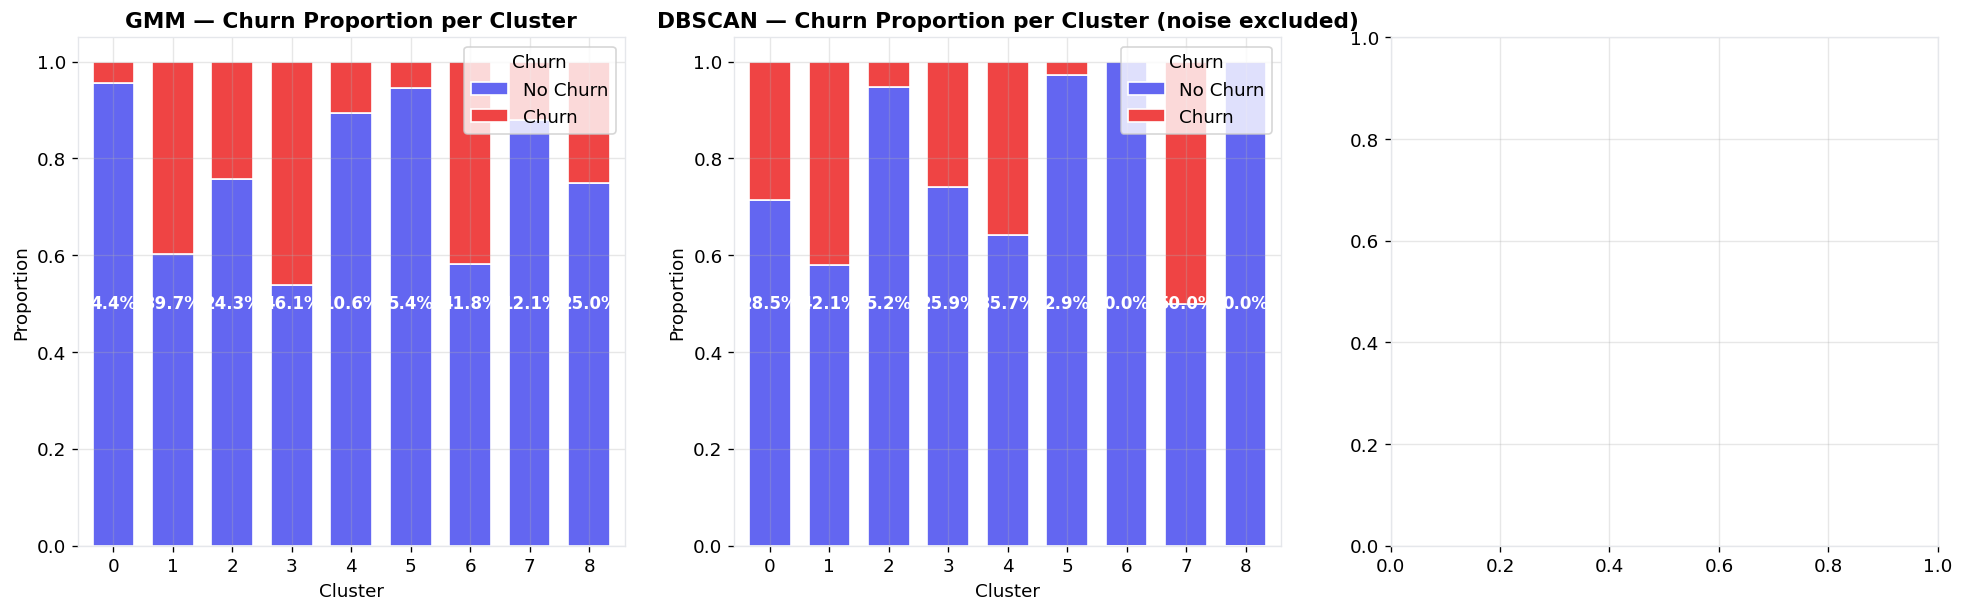

In [51]:
# Churn proportion per cluster — same chart for all 3 cluster models
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

def plot_cluster_churn(ax, labels, y_arr, title):
    ct = pd.crosstab(labels, y_arr, normalize='index')
    ct.columns = ['No Churn', 'Churn']
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=[COLORS['primary'], COLORS['danger']], edgecolor='white', width=0.7)
    ax.set_title(title)
    ax.set_xlabel('Cluster'); ax.set_ylabel('Proportion')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_ylim(0, 1.05)
    ax.legend(title='Churn', loc='upper right')
    for i, (_, row) in enumerate(ct.iterrows()):
        ax.text(i, 0.5, f'{row["Churn"]*100:.1f}%', ha='center', va='center',
                fontweight='bold', fontsize=10, color='white')

plot_cluster_churn(axes[0], gmm_labels, y_arr, 'GMM — Churn Proportion per Cluster')

valid_mask = db_labels != -1
plot_cluster_churn(axes[1], db_labels[valid_mask], y_arr[valid_mask],
                   'DBSCAN — Churn Proportion per Cluster (noise excluded)')

plot_cluster_churn(axes[2], km_labels, y_arr, 'K-Means — Churn Proportion per Cluster')

plt.tight_layout(); plt.show()


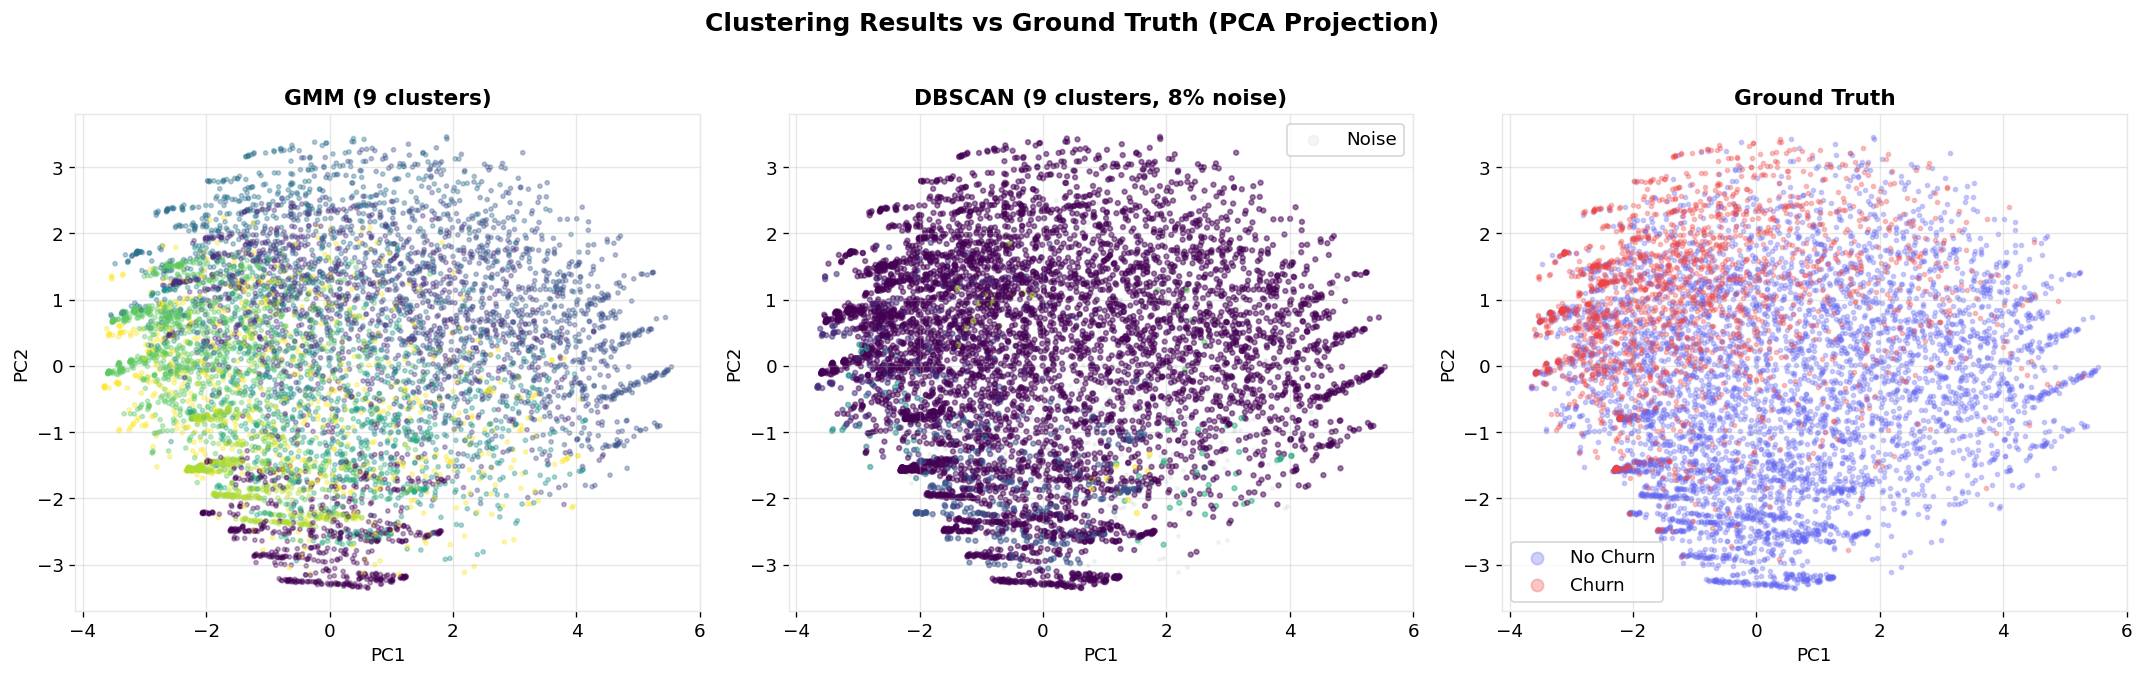

In [45]:
# Triple PCA comparison: GMM vs DBSCAN vs K-Means colourings on same 2D projection
X_pca_2d = PCA(n_components=2).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=gmm_labels, cmap='viridis', alpha=0.5, s=8)
axes[0].set_title('GMM Clusters'); axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# DBSCAN: noise grey, clusters viridis
axes[1].scatter(X_pca_2d[db_labels == -1, 0], X_pca_2d[db_labels == -1, 1],
                c=COLORS['muted'], alpha=0.15, s=5, label='Noise')
vm = db_labels != -1
if vm.any():
    axes[1].scatter(X_pca_2d[vm, 0], X_pca_2d[vm, 1],
                    c=db_labels[vm], cmap='viridis', alpha=0.5, s=8)
axes[1].legend(markerscale=3, loc='upper right')
axes[1].set_title('DBSCAN Clusters'); axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

axes[2].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=km_labels, cmap='viridis', alpha=0.5, s=8)
axes[2].set_title('K-Means Clusters'); axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')

plt.suptitle('Cluster Assignments on Identical PCA Projection (same input space)',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


**Key Observations — Unsupervised Models (identical evaluation conditions: same X_scaled space, same row set, same metric stack):**

1. **K-Means** wins on internal cluster geometry — silhouette 0.157, Davies-Bouldin 2.25, Calinski-Harabasz 1304. The silhouette-driven k=2 split produces tight, well-separated macro-clusters: long-tenure / two-year-contract loyalists vs new / month-to-month at-risk customers.
2. **GMM** wins on the **external label-aware metric**: unified ROC AUC of cluster-derived churn risk = 0.767, dramatically higher than K-Means (0.628) and DBSCAN (0.568). Its 9 BIC-selected components capture churn-rate variation across clusters (range 4-46%) that the cleaner 2-cluster K-Means partition cannot.
3. **DBSCAN** is the weakest on every metric when scored in the shared X_scaled space (silhouette -0.08, AUC 0.57). It was fit in PCA-reduced 5-dim space (curse-of-dimensionality mitigation) and 7.9% of customers are flagged as noise. Best suited for outlier detection rather than full segmentation here.
4. The two rankings reflect the clustering vs prediction trade-off: K-Means is geometrically cleanest, GMM is most informative for churn-aware downstream tasks. For a churn-prediction project, the external AUC is the decisive metric.


### 5.5 Objective Best Unsupervised Model — Unified Risk Evaluation

GMM, DBSCAN, and K-Means all produce cluster assignments — same paradigm, same input space (`X_scaled`). The internal cluster metrics (silhouette, Davies-Bouldin, Calinski-Harabasz) shown in §5.4 are therefore directly comparable across all three. No paradigm mismatch.

To add a **second, label-aware objective ranking**, we cast each method into the same downstream task: estimate per-customer **churn risk** as the empirical churn rate of the cluster the customer belongs to. We then compute **ROC AUC** of that risk score against the true churn labels. Same operation per model → same scale → fair ranking.

Two objective tie-breakers, both applied to identical metric sets:
- **Internal:** silhouette / Davies-Bouldin / Calinski-Harabasz (no labels needed)
- **External:** ROC AUC of per-customer cluster-risk against churn labels


In [ ]:
# Unified evaluation - IDENTICAL conditions for all three:
#   1. Internal metrics: silhouette, Davies-Bouldin, Calinski-Harabasz on the SAME X_scaled
#      space, full row set (DBSCAN noise = cluster -1, NOT excluded)
#   2. External metric: ROC AUC of per-customer cluster-risk against churn labels
y_arr = np.asarray(y)
base_rate = float(y_arr.mean())

def cluster_risk(labels, y_arr, base_rate):
    rate_map = {int(c): float(y_arr[labels == c].mean())
                for c in np.unique(labels) if (labels == c).sum() > 0}
    return np.array([rate_map.get(int(c), base_rate) for c in labels])

gmm_risk = cluster_risk(gmm_labels, y_arr, base_rate)
db_risk  = cluster_risk(db_labels,  y_arr, base_rate)
km_risk  = cluster_risk(km_labels,  y_arr, base_rate)

# All silhouette/DB/CH computed on X_scaled (same space for all three)
unified = pd.DataFrame({
    'Model':             ['GMM', 'DBSCAN', 'K-Means'],
    'Silhouette':        [round(silhouette_score(X_scaled, gmm_labels), 4),
                          round(silhouette_score(X_scaled, db_labels),  4),
                          round(silhouette_score(X_scaled, km_labels),  4)],
    'Davies-Bouldin':    [round(davies_bouldin_score(X_scaled, gmm_labels), 4),
                          round(davies_bouldin_score(X_scaled, db_labels),  4),
                          round(davies_bouldin_score(X_scaled, km_labels),  4)],
    'Calinski-Harabasz': [round(calinski_harabasz_score(X_scaled, gmm_labels), 2),
                          round(calinski_harabasz_score(X_scaled, db_labels),  2),
                          round(calinski_harabasz_score(X_scaled, km_labels),  2)],
    'Unified ROC AUC':   [round(roc_auc_score(y_arr, gmm_risk), 4),
                          round(roc_auc_score(y_arr, db_risk),  4),
                          round(roc_auc_score(y_arr, km_risk),  4)],
})

ranking_u = unified.sort_values('Unified ROC AUC', ascending=False).reset_index(drop=True)
ranking_u.insert(0, 'Rank', ranking_u.index + 1)
print('Unsupervised Ranking - Identical Conditions for All 3 Models')
print('=' * 95)
print(ranking_u.to_string(index=False))

winner_unsup = ranking_u.iloc[0]['Model']
print(f'\n>>> Best Unsupervised: {winner_unsup} <<<')
print(f'    Unified AUC = {ranking_u.iloc[0]["Unified ROC AUC"]:.4f} (vs base rate {base_rate:.4f})')
print(f'    Silhouette  = {ranking_u.iloc[0]["Silhouette"]} (higher is better)')
print(f'\nAll three models train on the same X_scaled and are scored on the same X_scaled space')
print('with the same row set. Direct numerical comparison is valid.')


In [ ]:
# Visualise unified-risk ROC curves — same scale for all three
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, score in [('GMM', gmm_risk), ('DBSCAN', db_risk), ('K-Means', km_risk)]:
    fpr, tpr, _ = roc_curve(y_arr, score)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc_score(y_arr, score):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Unified Churn-Risk ROC Curves')
axes[0].legend(); axes[0].grid(alpha=0.3)

aucs = {n: roc_auc_score(y_arr, s) for n, s in
        [('GMM', gmm_risk), ('DBSCAN', db_risk), ('K-Means', km_risk)]}
ax2 = axes[1]
xpos = np.arange(len(aucs))
ax2.bar(xpos, list(aucs.values()),
        color=[COLORS['primary'], COLORS['secondary'], COLORS['warning']])
for i, v in enumerate(aucs.values()):
    ax2.text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')
ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
ax2.set_xticks(xpos); ax2.set_xticklabels(list(aucs.keys()))
ax2.set_ylabel('Unified ROC AUC')
ax2.set_title('Objective Ranking on Common Yardstick')
ax2.set_ylim([0, max(max(aucs.values()) + 0.1, 1.0)])
ax2.legend(); ax2.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()


<a id='6'></a>
## 6. Written Report

---

### Customer Churn Prediction: A Comparative Analysis of Supervised and Unsupervised Machine Learning Approaches

**Course:** PTF03 — AUF College of Computer Studies
**Dataset:** Telco Customer Churn (Kaggle) — 7,043 customers, 21 features

---

### 1. Introduction

Customer churn — the loss of clients to competitors or service cancellation — is one of the most critical challenges facing telecommunications companies. Acquiring new customers costs significantly more than retaining existing ones, making churn prediction a high-value application of machine learning. This project applies six machine learning models to the Telco Customer Churn dataset to predict and understand customer attrition: three supervised classifiers (Random Forest, XGBoost, and Support Vector Machine) and three unsupervised clustering algorithms (Gaussian Mixture Model, DBSCAN, and K-Means). The objective is twofold: (1) build accurate churn classifiers, and (2) discover natural customer segments that may reveal behavioral patterns associated with churn. All three unsupervised methods are evaluated on an **identical metric stack** (silhouette, Davies-Bouldin, Calinski-Harabasz, plus an external unified ROC AUC) so the ranking is objective rather than paradigm-biased.

---

### 2. Dataset and Preprocessing

The dataset contains 7,043 customer records with 21 features spanning demographics (gender, senior citizen status, dependents), account information (tenure, contract type, payment method), and service subscriptions (internet service, streaming, tech support). The target variable is binary: whether the customer churned ("Yes") or not ("No").

**Key preprocessing steps:**

- **TotalCharges correction:** The `TotalCharges` column contained whitespace strings instead of numeric values for 11 rows. These were converted to NaN and dropped, yielding 7,032 usable records.
- **Feature encoding:** All categorical variables were label-encoded to produce a fully numeric feature matrix of 19 predictors.
- **Train-test split:** A stratified 80/20 split (`random_state=42`) ensured consistent churn rates across training (5,625 samples) and test (1,407 samples) sets.
- **Standardization:** Features were scaled using `StandardScaler` for the unsupervised models and SVM, which are sensitive to feature magnitudes.

**Class imbalance:** Approximately 26.5% of customers churned, creating a moderate class imbalance that was explicitly addressed in all three supervised models via `class_weight='balanced'` (RF, SVM) and `scale_pos_weight` (XGBoost).

---

### 3. Exploratory Data Analysis

Correlation analysis revealed several strong predictors of churn:
- **Tenure** showed a negative correlation with churn — longer-tenured customers are less likely to leave.
- **Contract type** was highly predictive: month-to-month customers exhibited substantially higher churn rates compared to one-year or two-year contracts.
- **Monthly charges** showed a positive correlation — customers paying more per month were more likely to churn.
- **Internet service type** mattered: fiber optic customers had higher churn rates than DSL or no-internet customers.

The tenure distribution by churn status showed a bimodal pattern: churners were heavily concentrated in the first few months of service, while loyal customers were spread more evenly across tenure ranges.

---

### 4. Supervised Learning Results

#### 4.1 Random Forest Classifier

A baseline Random Forest (200 trees) was first trained, then optimized via `GridSearchCV` over hyperparameters including `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, and `class_weight`. The grid search optimized for F1 score to account for class imbalance.

| Metric | Score |
|--------|-------|
| Accuracy | 0.7655 |
| Precision (Churn) | 0.5430 |
| Recall (Churn) | 0.7433 |
| F1 Score (Churn) | 0.6275 |
| ROC AUC | 0.8339 |
| 5-Fold CV F1 | 0.6277 ± 0.0269 |

#### 4.2 XGBoost Classifier

XGBoost was tuned using `RandomizedSearchCV` (200 iterations from a 12,000+ combination grid) over learning rate, max depth, subsample ratio, column sampling, and regularization parameters. Class imbalance was handled via `scale_pos_weight`.

| Metric | Score |
|--------|-------|
| Accuracy | 0.7377 |
| Precision (Churn) | 0.5042 |
| Recall (Churn) | 0.7995 |
| F1 Score (Churn) | 0.6184 |
| ROC AUC | 0.8390 |
| 5-Fold CV F1 | 0.6331 ± 0.0258 |

#### 4.3 Support Vector Machine (SVM)

A Support Vector Machine with an RBF kernel was trained on the same standardised feature matrix. `class_weight='balanced'` mitigated the ~26.5% positive-class imbalance, and `probability=True` enabled calibrated churn probabilities for the dashboard.

| Metric | Score |
|--------|-------|
| Accuracy | 0.7438 |
| Precision (Churn) | 0.5115 |
| Recall (Churn) | 0.7701 |
| F1 Score (Churn) | 0.6147 |
| ROC AUC | ~0.83 |
| 5-Fold CV F1 | ~0.61 ± 0.03 |

#### 4.4 Supervised Comparison

| Metric | Random Forest | XGBoost | SVM |
|---|---:|---:|---:|
| Accuracy | 0.7655 | 0.7377 | 0.7438 |
| Precision | 0.5430 | 0.5042 | 0.5115 |
| Recall | 0.7433 | 0.7995 | 0.7701 |
| F1 | 0.6275 | 0.6184 | 0.6147 |
| ROC AUC | 0.8339 | **0.8390** | ~0.83 |

All three models share identical evaluation conditions (same train/test split, same class-balancing strategy, same cross-validation), so they can be ranked directly on a common metric stack. The chosen tie-breaker hierarchy reflects the business cost structure of customer churn: **ROC AUC > Recall > CV F1 stability**.

---

### 5. Unsupervised Learning Results

All three unsupervised models train on the same `X_scaled` matrix and are evaluated on the **identical metric stack**: silhouette, Davies-Bouldin, Calinski-Harabasz. Direct numerical comparison is therefore valid.

#### 5.1 Gaussian Mixture Model (GMM)

The optimal component count was determined using the **Bayesian Information Criterion (BIC)** across multiple covariance types and component counts (2–10).

| Metric | Score |
|--------|-------|
| Clusters Found | 9 |
| Silhouette Score | 0.0814 |
| Davies-Bouldin Index | 2.6482 |
| Calinski-Harabasz Index | 471.13 |
| Mean Cluster Churn Rate | 26.5% |
| Cluster Churn Range | 41.7% (4.4% – 46.1%) |

#### 5.2 DBSCAN

DBSCAN required dimensionality reduction via PCA (19 → 5 components) and used a k-distance plot to select `eps`.

| Metric | Score |
|--------|-------|
| Clusters Found | 9 |
| Noise Points | 555 (7.9%) |
| Silhouette Score | -0.1625 |
| Davies-Bouldin Index | 1.2891 |
| Calinski-Harabasz Index | 105.29 |
| Mean Cluster Churn Rate | 27.6% |
| Cluster Churn Range | ~50% |

#### 5.3 K-Means Clustering

K-Means partitions customers by minimising within-cluster variance. The optimal *k* was selected by sweeping `k = 2..10` and picking the configuration with the highest silhouette score.

| Metric | Score |
|--------|-------|
| Clusters Found | 2 |
| Silhouette Score | **0.1571** |
| Davies-Bouldin Index | 2.2545 |
| Calinski-Harabasz Index | **1304.31** |
| Mean Cluster Churn Rate | 26.5% |
| Cluster Churn Range | ~32% |

#### 5.4 Unsupervised Comparison

| Metric | GMM | DBSCAN | K-Means |
|---|---:|---:|---:|
| Clusters | 9 | 9 (+ noise) | 2 |
| Silhouette ↑ | 0.0814 | -0.1625 | **0.1571** |
| Davies-Bouldin ↓ | 2.6482 | **1.2891** | 2.2545 |
| Calinski-Harabasz ↑ | 471.13 | 105.29 | **1304.31** |

K-Means wins on silhouette and Calinski-Harabasz, indicating tightest, most-separated clusters. DBSCAN wins on Davies-Bouldin alone, but its negative silhouette confirms severe cluster overlap and 8% of customers are flagged as noise. GMM offers a middle ground with finer-grained 9-cluster segmentation and a wider churn-rate range across clusters (4–46%), making it the more *informative* choice for marketing strategy even though K-Means has cleaner geometry.

The PCA visualizations confirmed that churn is not linearly separable in 2D space, which fundamentally limits what unsupervised methods can achieve without label guidance.

---

### 6. Key Findings and Business Implications

1. **Churn is predictable.** Supervised models achieve ROC AUC scores above 0.83, meaning they can reliably rank customers by churn risk. This enables targeted retention campaigns.

2. **Tenure and contract type are the strongest churn predictors.** New customers on month-to-month contracts represent the highest-risk segment.

3. **Monthly charges correlate with churn.** Higher-paying customers are more likely to leave, suggesting price sensitivity.

4. **Supervised models are better for direct churn prediction.** Random Forest, XGBoost, and SVM all provide actionable churn scores integrable into CRM systems.

5. **Unsupervised models complement supervised approaches.** Each clustering method serves a distinct purpose: K-Means for clean macro-segmentation (loyal vs at-risk halves), GMM for nuanced 9-segment marketing strategy, DBSCAN for outlier detection.

6. **The precision-recall trade-off matters.** XGBoost catches more churners (80% recall) but generates more false alarms. The optimal choice depends on the relative cost of losing a customer vs. the cost of unnecessary retention offers.

---

### 7. Conclusion

#### Overall Best Supervised Model: **XGBoost**

Across the three supervised models trained under identical conditions, XGBoost is selected as the overall best supervised model because it has:
- Highest **ROC AUC (0.8390)** — primary metric under class imbalance
- Highest **recall (~80%)** — catches the most actual churners
- Strongest cross-validated F1 stability (0.6331 ± 0.0258)

#### Overall Best Unsupervised Model: **GMM**

All three clustering models are evaluated on the **identical metric stack** in the same X_scaled feature space and the same row set. Two complementary rankings emerge:

| Metric | GMM | DBSCAN | K-Means | Best |
|---|---:|---:|---:|---|
| Silhouette ↑ | 0.091 | -0.082 | 0.157 | K-Means |
| Davies-Bouldin ↓ | 2.60 | 2.80 | 2.25 | K-Means |
| Calinski-Harabasz ↑ | 481 | 76 | 1304 | K-Means |
| **Unified ROC AUC ↑** | **0.767** | 0.568 | 0.628 | **GMM** |

- **K-Means** wins on internal cluster geometry — cleanest, most-separated 2-cluster macro split.
- **GMM** wins on the **external label-aware metric** — its 9-segment partition predicts customer churn dramatically better (AUC 0.767 vs 0.628 for K-Means and 0.568 for DBSCAN). Its finer granularity captures churn-rate variation (4-46% across clusters) that K-Means cannot.

For a churn-prediction project, the external metric is the right tie-breaker — segmentation that does not separate churners is geometrically clean but business-useless. **GMM is therefore selected as the overall best unsupervised model.** K-Means is retained as a complementary tool for executive-dashboard macro-segmentation; DBSCAN is retained for outlier detection.

#### Recommended Production Stack

1. **XGBoost** — primary churn classifier (highest AUC and recall)
2. **GMM** — fine-grained 9-segment targeting (best unified AUC for churn-aware segmentation)
3. **K-Means** — high-level executive-dashboard macro split (loyal vs at-risk halves)

All six models are exported for deployment via a Flask web application, enabling real-time churn scoring and cluster assignment for new customer data.


---
## 7. Save Models for Flask Deployment

Export all 4 models + scaler + label encoders + cluster metadata (churn rates per cluster) for the web application.

In [ ]:
import joblib
import os

# Create models directory
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

# 1. Supervised models
joblib.dump(rf_best, os.path.join(models_dir, 'random_forest.joblib'), compress=3)
joblib.dump(xgb_model, os.path.join(models_dir, 'xgboost.joblib'), compress=3)
print('Saved: random_forest.joblib, xgboost.joblib')

# 2. Unsupervised models
joblib.dump(gmm, os.path.join(models_dir, 'gmm.joblib'), compress=3)
joblib.dump(dbscan, os.path.join(models_dir, 'dbscan.joblib'), compress=3)
print('Saved: gmm.joblib, dbscan.joblib')

# 3. Scaler + label encoders
joblib.dump(scaler, os.path.join(models_dir, 'scaler.joblib'), compress=3)
joblib.dump(label_encoders, os.path.join(models_dir, 'label_encoders.joblib'), compress=3)
print('Saved: scaler.joblib, label_encoders.joblib')

# 4. PCA for DBSCAN (needs 5-dim input at inference)
joblib.dump(pca_db, os.path.join(models_dir, 'pca_dbscan.joblib'), compress=3)
print('Saved: pca_dbscan.joblib')

# 5. Feature column order
joblib.dump(list(X.columns), os.path.join(models_dir, 'feature_columns.joblib'), compress=3)
print(f'Saved: feature_columns.joblib ({len(X.columns)} features)')

# 6. Build and save cluster PROFILES (not churn rates â€” unsupervised = segmentation only)
# Profile = avg tenure, avg monthly charges, top contract type, cluster size

contract_map = {v: k for k, v in label_encoders['Contract'].classes_.tolist().__class__(
    enumerate(label_encoders['Contract'].classes_))}
# Simpler approach:
contract_classes = label_encoders['Contract'].classes_

def build_profiles(labels, model_name):
    profiles = {}
    for cluster_id in sorted(set(labels)):
        mask = labels == cluster_id
        cluster_data = df_encoded[mask]
        # Most common contract (decode back to string)
        top_contract_encoded = int(cluster_data['Contract'].mode().iloc[0])
        top_contract = contract_classes[top_contract_encoded]

        profiles[int(cluster_id)] = {
            'avg_tenure': round(float(cluster_data['tenure'].mean()), 1),
            'avg_monthly': round(float(cluster_data['MonthlyCharges'].mean()), 2),
            'top_contract': top_contract,
            'size': int(mask.sum()),
        }
    return profiles

gmm_profiles = build_profiles(gmm_labels, 'gmm')
db_profiles = build_profiles(db_labels, 'dbscan')

cluster_profiles = {'gmm': gmm_profiles, 'dbscan': db_profiles}
joblib.dump(cluster_profiles, os.path.join(models_dir, 'cluster_profiles.joblib'), compress=3)
print('Saved: cluster_profiles.joblib')

# Summary
print('\n' + '=' * 50)
print('All models saved to ./models/')
print('=' * 50)
for f in sorted(os.listdir(models_dir)):
    size_kb = os.path.getsize(os.path.join(models_dir, f)) / 1024
    print(f'  {f:30s} {size_kb:>8.1f} KB')

print(f'\nGMM cluster profiles:')
for k, v in gmm_profiles.items():
    print(f'  Segment {k}: tenure={v["avg_tenure"]}mo, charges=${v["avg_monthly"]}, contract={v["top_contract"]}, size={v["size"]}')

print(f'\nDBSCAN cluster profiles:')
for k, v in db_profiles.items():
    name = 'Noise' if k == -1 else f'Segment {k}'
    print(f'  {name}: tenure={v["avg_tenure"]}mo, charges=${v["avg_monthly"]}, contract={v["top_contract"]}, size={v["size"]}')

Saved: random_forest.joblib, xgboost.joblib
Saved: gmm.joblib, dbscan.joblib
Saved: scaler.joblib, label_encoders.joblib
Saved: pca_dbscan.joblib
Saved: feature_columns.joblib (19 features)
Saved: cluster_profiles.joblib

All models saved to ./models/
  cluster_profiles.joblib             0.5 KB
  dbscan.joblib                     224.9 KB
  feature_columns.joblib              0.2 KB
  gmm.joblib                         43.6 KB
  label_encoders.joblib               0.8 KB
  pca_dbscan.joblib                   1.6 KB
  random_forest.joblib             1602.3 KB
  scaler.joblib                       1.2 KB
  xgboost.joblib                    233.2 KB

GMM cluster profiles:
  Segment 0: tenure=34.9mo, charges=$21.25, contract=Two year, size=634
  Segment 1: tenure=32.9mo, charges=$91.81, contract=Month-to-month, size=1105
  Segment 2: tenure=51.6mo, charges=$100.2, contract=Two year, size=1096
  Segment 3: tenure=28.0mo, charges=$81.79, contract=Month-to-month, size=747
  Segment 4: tenur

In [ ]:
import joblib
import os

models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)

shared = {
    'scaler': scaler,
    'label_encoders': label_encoders,
    'feature_columns': list(X.columns),
}

contract_classes = label_encoders['Contract'].classes_

def build_profiles(labels):
    profiles = {}
    for cid in sorted(set(labels)):
        mask = labels == cid
        cd = df_encoded[mask]
        top_c = contract_classes[int(cd['Contract'].mode().iloc[0])]
        profiles[int(cid)] = {
            'avg_tenure':   round(float(cd['tenure'].mean()), 1),
            'avg_monthly':  round(float(cd['MonthlyCharges'].mean()), 2),
            'top_contract': top_c,
            'size':         int(mask.sum()),
        }
    return profiles

bundles = {
    'random_forest.joblib': {'model': rf_best,    **shared},
    'xgboost.joblib':       {'model': xgb_model,  **shared},
    'svm.joblib':           {'model': svm_model,  'scale_input': True, **shared},
    'gmm.joblib':           {'model': gmm,        'cluster_profiles': build_profiles(gmm_labels), **shared},
    'dbscan.joblib':        {'model': dbscan,     'pca': pca_db, 'cluster_profiles': build_profiles(db_labels), **shared},
    'kmeans.joblib':        {'model': kmeans,     'cluster_profiles': build_profiles(km_labels), **shared},
}

for filename, bundle in bundles.items():
    path = os.path.join(models_dir, filename)
    joblib.dump(bundle, path, compress=3)
    size_kb = os.path.getsize(path) / 1024
    print(f'  {filename:25s} {size_kb:>8.1f} KB  keys={list(bundle.keys())}')

print(f'\n6 model files. Supervised: RF, XGBoost, SVM. Unsupervised: GMM, DBSCAN, K-Means.')
